In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))
sys.path.append(str(project_root / "src"))

In [2]:
# Import necessary libraries
import base64
import contextlib
import diptest
import io
from io import BytesIO
from IPython.display import HTML, display
import itertools as it
from matplotlib import colormaps
import matplotlib.pyplot as plt
from pathlib import Path
import pypdfium2 as pdfium
import numpy as np
import pandas as pd
from scipy.stats import wasserstein_distance, ks_2samp
from scipy.stats import cramervonmises_2samp
import tempfile

# Import custom modules
from src.compose_panels import compose_panels
from src.interactions import plot as pt
from src.itese_dataviz.shapiq import CeaInteractionValues
from src.itese_dataviz.linezoomgrid import LineZoomHistGridPlot
import src.config
import src.style

# Load data

In [3]:
data = pd.read_parquet('./../data/B_modeloutput.parquet')
ar6 = pd.read_parquet('./../data/B_ar6benchmark.parquet')
indices = pd.read_parquet('./../data/B_interactions.parquet')
indices_simple = pd.read_parquet('./../data/B_interactions_simple.parquet')

In [4]:
REGION = 'World'
TIME = 2050

# Filter data and rename columns for clarity
dataw = data[(data['Region']==REGION) & (data['Period']<=TIME)]
dataw.rename(columns={'ClimatePolicy': 'CP',
                     'SocioEconomics': 'DS',
                     'GeologicalSequestrationPotential': 'GCSP',
                     'SustainableBiomassPotential': 'SBP',
                     'DirectElectrification': 'DEL',
                     'H2Electrification': 'HEL',
                     'EfuelsElectrification': 'EEL'},
            inplace=True)
dataw2050 = dataw[dataw['Period']==TIME]

# Table 3
<a id="table-3"></a>
## Comparison against IPCC-AR6

In [5]:
# Filter datas
emiref = np.array(dataw2050['EMITOT'].values)
ar6w2050 = ar6[(ar6['Region']==REGION) & (ar6['Year']==TIME)]

# Variable initialization
categories = []
size = []
distances = []
ks = []
ksp = []
cvm = []
cvmp = []

# Compute distances and statistics for each category
for i in range(1, 9):
    categories.append('C1-C'+str(i))
    cats = ['C'+str(j) for j in range(1,i+1)]
    emialt = np.array(ar6w2050[(ar6w2050['Category'].isin(cats)) & ~(ar6w2050['Emissions|CO2|Energy'].isna())]['Emissions|CO2|Energy'].values/1000)
    size.append(len(emialt))
    distances.append(round(wasserstein_distance(emiref, emialt), 3))
    ks.append(round(ks_2samp(emiref, emialt, alternative="two-sided").statistic, 3))
    ksp.append(round(ks_2samp(emiref, emialt, alternative="two-sided").pvalue, 3))
    cvm.append(round(cramervonmises_2samp(emiref, emialt).statistic, 3))
    cvmp.append(round(cramervonmises_2samp(emiref, emialt).pvalue, 3))

pd.DataFrame(data={
    'AR6 categories': categories,
    'Sample size': size,
    'Wasserstein': distances,
    'KS': ks,
    'KS-pvalue': ksp,
    'Cramer': cvm,
    'Cramer-pvalue': cvmp})

,AR6 categories,Sample size,Wasserstein,KS,KS-pvalue,Cramer,Cramer-pvalue
0,C1-C1,78,8.789,0.669,0.000,13.742,0.000
1,C1-C2,188,6.391,0.440,0.000,14.226,0.000
2,C1-C3,454,3.283,0.234,0.000,5.817,0.000
3,C1-C4,586,1.299,0.098,0.004,0.899,0.004
4,C1-C5,768,2.722,0.157,0.000,2.809,0.000
5,C1-C6,846,4.517,0.225,0.000,6.673,0.000
6,C1-C7,942,7.363,0.298,0.000,12.604,0.000
7,C1-C8,949,7.775,0.303,0.000,13.068,0.000


**Comparison of AR6 scenario categories against this study.** Benchmark is done on world energy-related $CO_{2}$ emissions in 2050.

# Figure 6
<a id="figure-6"></a>
### Changes in energy-related $CO_{2}$ emissions

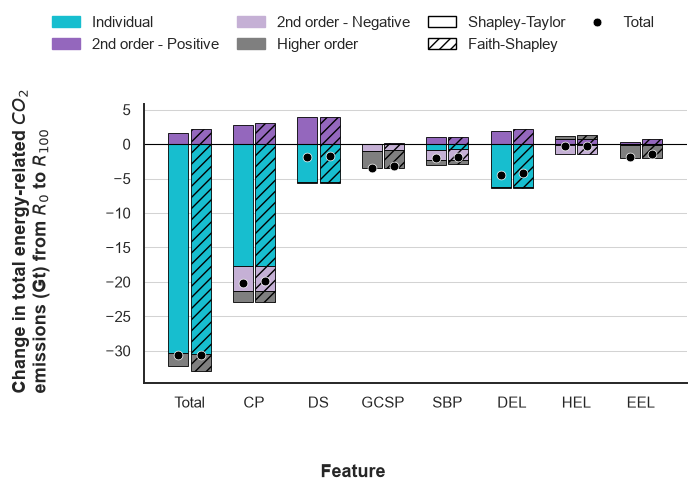

In [6]:
# Filter indices
indicators = ['EMITOT']
regions = ['World']
cstep = '0-100'
methods = ['Shapley-Taylor', 'Faith-Shapley']
mode = 'absolute'
ims = indices_simple[
    (indices_simple['method'].isin(methods)) &\
    (indices_simple['mode']==mode)  &\
    (indices_simple['Region'].isin(regions)) &\
    (indices_simple['Indicator'].isin(indicators)) &\
    (indices_simple['ClimateStep']==cstep)]
ims.drop(columns=['Abs(Contribution)', 'mode'], inplace=True)

# Assign sectors and pathways
ims['Sector'] = None
ims.loc[ims['Indicator'].str.startswith('FIN'), 'Sector'] = 'Total final'
ims.loc[ims['Indicator'].str.startswith('TRA'), 'Sector'] = 'Transport'
ims.loc[ims['Indicator'].str.startswith('IND'), 'Sector'] = 'Industry'
ims.loc[ims['Indicator'].str.startswith('BLG'), 'Sector'] = 'Buildings'
ims['Pathway'] = None
ims.loc[ims['Indicator'].str.endswith('TELsh'), 'Pathway'] = 'Total elec.'
ims.loc[ims['Indicator'].str.endswith('DELsh'), 'Pathway'] = 'Direct elec.'
ims.loc[ims['Indicator'].str.endswith('HELsh'), 'Pathway'] = '$H_{2}$ elec.'
ims.loc[ims['Indicator'].str.endswith('SELsh'), 'Pathway'] = 'Efuels elec.'

# Define labels
labels = {'TRADELsh': 'Direct', 'TRAHELsh': '$H_{2}$', 'TRASELsh': 'Efuels',
          'INDDELsh': 'Direct', 'INDHELsh': '$H_{2}$', 'BLGDELsh': 'Direct',
          'FINDELsh': 'Direct', 'FINHELsh': '$H_{2}$', 'FINSELsh': 'Efuels'}

# Filter, sort data, define layout and style
methods = ['Shapley-Taylor', 'Faith-Shapley']
imsm = ims[ims['method'].isin(methods)]
coalitions = ['Total', 'CP', 'DS', 'GCSP', 'SBP', 'DEL', 'HEL', 'EEL']
effects = ['Individual', '2nd order - Positive', '2nd order - Negative', 'Higher order']
palette = {'Individual': colormaps['tab20'].colors[18],
           '2nd order - Positive': colormaps['tab20'].colors[8],
           '2nd order - Negative': colormaps['tab20'].colors[9],
           'Higher order': colormaps['tab20'].colors[14],
           'Total': colormaps['tab20'].colors[10]}
custom_sort = {'Individual': 0,
               '2nd order - Positive': 1,
               '2nd order - Negative': 2,
               'Higher order': 3,
               'Total': 4}
imsm.sort_values(by='effect',
                 key=lambda x: x.map(custom_sort),
                 inplace=True) 
encode = pt.encodings.allocations(x='coalition',
                                  y='Contribution',
                                  color='effect',
                                  compare='method',
                                  category_orders={'coalition': coalitions},
                                  color_order=effects,)
y_title = r'Change in total energy-related $CO_{2}$' '\n' r'emissions (Gt) from $R_{0}$ to $R_{100}$'
style = pt.Style(palette=palette,
                 reverse_palette=True)
layout = pt.Layout(x_title='Feature',
                   y_title=y_title,
                   x_title_offset=20,)

# Plot
pt.plot_allocations(imsm,
                    encode,
                    backend='matplotlib',
                    scatter_category={'effect': 'Total'},
                    layout=layout,
                    style=style
                    );

**Decomposition of the change in energy-related $CO_{2}$ emissions between $R_{0}$ and $R_{100}$.** Each stacked bar represents, the decomposition of the change in energy-related $CO_{2}$ emissions, summed over interaction orders (first, second positive, second negative, higher), irrespectively of the involved features. The net effect is shown as black dots. For each sector and pathway, the Shapley-Taylor (plain) and Faithful-Shapley (hatched) decompositions are presented.

# Table 4
<a id="table-4"></a>
## Hartigan unimodality tests for transport electrification

In [7]:
def bimodality_diagnostics(values, cp_levels, switch=None, n_boot=20000, seed=1):
    """Test unimodality of an outcome distribution within each carbon-price layer.

    Runs Hartigan's dip test separately on each carbon-price level, so that the
    result cannot be produced by the carbon-price gradient itself, and corrects
    for multiple testing across levels. Adds a pooled Gaussian-mixture BIC
    comparison as corroboration, and — if a candidate switch feature is supplied
    — repeats the dip test within each of its two branches.

    Parameters
    ----------
    values : array_like of float, shape (n,)
        Outcome for each scenario (e.g. share of electricity in transport TFC).
    cp_levels : array_like, shape (n,)
        Carbon-price level of each scenario. One dip test is run per unique value.
    switch : array_like of int, shape (n,), optional
        Binary feature hypothesised to generate the two modes (e.g. DEL). When
        given, conditional dip tests are run on each branch. Default is None.
    n_boot : int, optional
        Bootstrap replicates for the dip p-value. Default is 20000. Bootstrap
        calibration is preferred over table interpolation at n < 100.
    seed : int, optional
        Seed for the bootstrap. Default is 1.

    Returns
    -------
    per_level : list of dict
        One entry per carbon-price level with keys 'cp', 'n', 'dip', 'p_raw',
        'p_holm'.
    pooled : dict
        Keys 'bic_1', 'bic_2', 'delta_bic' (positive favours two components),
        'dip', 'p'.
    conditional : dict or None
        Keys 'branch_0' and 'branch_1', each a dict with 'n', 'dip', 'p'.
        None when `switch` is not supplied.

    Examples
    --------
    >>> per_level, pooled, cond = bimodality_diagnostics(y, cp, switch=del_high)
    >>> per_level[0]['p_holm'] < 0.05
    True
    >>> cond['branch_0']['p'] > 0.05  # unimodal once conditioned
    True
    """
    values = np.asarray(values, dtype=float)
    cp_levels = np.asarray(cp_levels)

    per_level = []
    for c in np.unique(cp_levels):
        xi = values[cp_levels == c]
        xi = np.sort(np.asarray(xi, dtype=float))
        dip, p = diptest.diptest(xi, sort_x=True, boot_pval=True, n_boot=n_boot, seed=seed)
        per_level.append({"Climate Policy": c, "Sample size": xi.size, "Dip": dip, "p_raw": p})

    return per_level

tradel = dataw2050[['TRATELsh']].values
cp = dataw2050[['CP']].values
pd.DataFrame(data=bimodality_diagnostics(tradel, cp))

,Climate Policy,Sample size,Dip,p_raw
0,0,64,0.218665,0.0000
1,10,64,0.205661,0.0000
2,20,64,0.194940,0.0000
3,30,64,0.176160,0.0000
4,40,64,0.173651,0.0000
5,50,64,0.162186,0.0000
6,60,64,0.152216,0.0000
7,70,64,0.134825,0.0000
8,80,64,0.117603,0.0000
9,90,64,0.106658,0.0000


**Hartigan dip test for unimodality, by carbon-price layer.** Transport electrification in 2050, tested separately within each of the 11 carbon-price levels ($n=64$ scenarios per level, the full factorial over the six binary features).

# Figure 7
<a id="figure-7"></a>
## Electrification regimes in transport

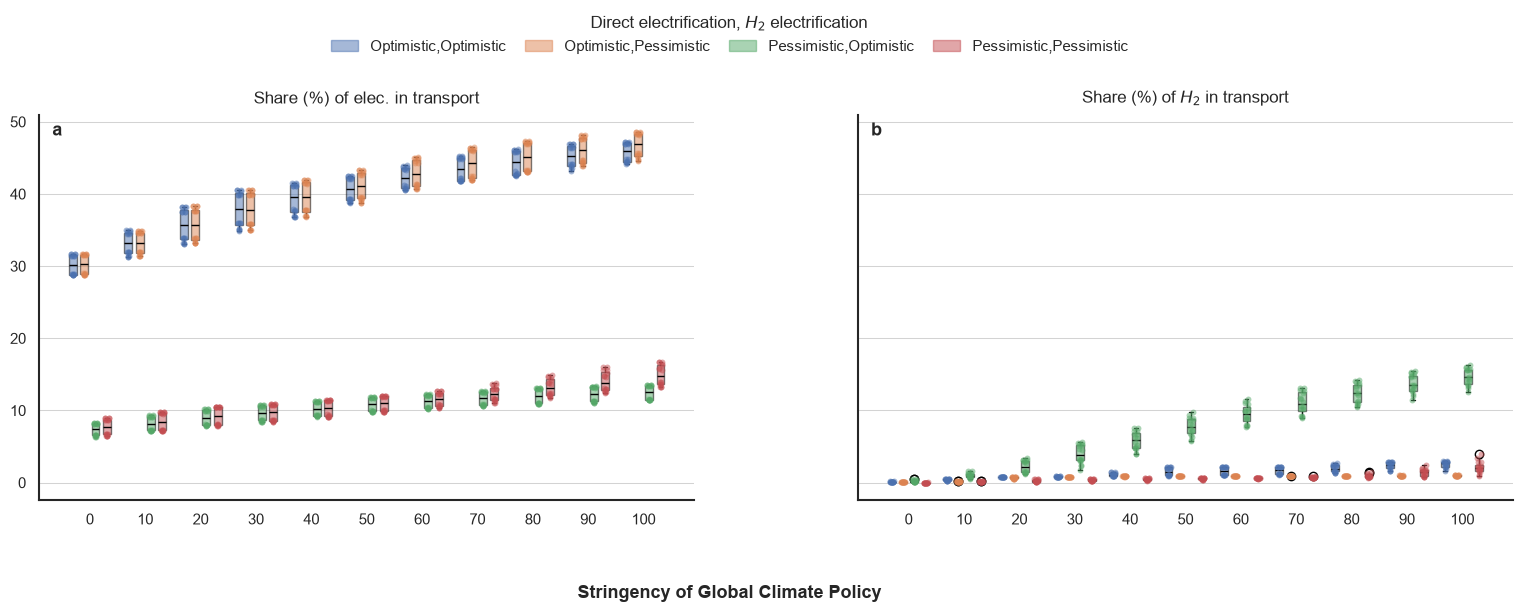

In [8]:
# Filter and preprocess data for electrification balance plot
elbalance = dataw2050[['Case', 'CP', 'DEL',
                       'HEL', 'TRADELsh', 'TRAHELsh']]
elbalance['DEL,HEL'] = elbalance['DEL'] + ',' + elbalance['HEL']

var_names = {'TRADELsh': 'Share (%) of elec. in transport',
             'TRAHELsh': 'Share (%) of $H_{2}$ in transport',
             "DEL,HEL": 'Direct electrification, $H_{2}$ electrification',
             'CP': 'Stringency of Global Climate Policy'}

# Sort data by Climate Policy
elbalance.sort_values(by="CP", ascending=True, inplace=True)

# Define plot encodings, layout, and style
e = pt.encodings.box(x="CP", y=['TRADELsh', 'TRAHELsh'],
                     color="DEL,HEL", labels=var_names)
layout = pt.Layout(panel_letters=True, share_y=True, wspace=0.25)
style=pt.Style(show_points=True,
               point_size=18,
               point_alpha=0.5,
               point_jitter=0.25,
               point_color=None)

# Plot
pt.grouped_boxplot(elbalance, e, show_total=False,
                   layout=layout, style=style);

**Shares of electricity and hydrogen in transport in 2050, World.** Each graph represents the shares of direct (**a**) or $H_{2}$ (**b**) in total final electricity consumption of transport. Each bar represent a combination of assumptions (Pessimistic/Optimistic) for the assumed rates of technical progress of electric or hydrogen-based technologies.

# Figure 8
<a id="figure-8"></a>


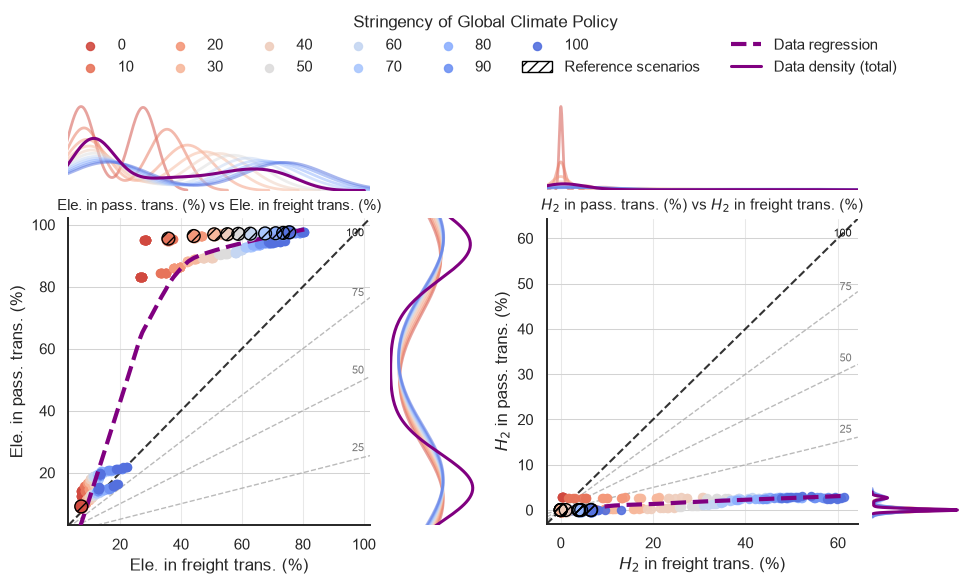

In [9]:
# Definer variable names and pairs
var_names = {'RFTRADELsh': 'Ele. in freight trans. (%)',
             'RPTRADELsh': 'Ele. in pass. trans. (%)',
             'RFTRAHELsh': '$H_{2}$ in freight trans. (%)',
             'RPTRAHELsh': '$H_{2}$ in pass. trans. (%)',
             'CP': 'Stringency of Global Climate Policy',
             'benchmark': 'AR6 benchmark',
             'LOESS (benchmark)': 'AR6 regression',
             'LOESS (data)': 'Data regression',
             'total': 'Data density (total)',
             'Highlight': 'Reference scenarios'}
var_pairs = [('RFTRADELsh', 'RPTRADELsh'), ('RFTRAHELsh', 'RPTRAHELsh')]
dataw2050 = dataw2050.sort_values(by=['CP'])

# Define encodings, style, regression, and layout
jointencoding = pt.encodings.joint(
  var_pairs=var_pairs,
  color='CP',
  category_orders={'CP': list(range(0, 101, 10))},
  labels=var_names)
style = pt.Style(
  palette='coolwarm',
  reverse_palette=True)
regression = pt.Regression(
  data=True,
  data_color='purple')
highlight = {'Case': [65, 192, 256, 320, 384, 448,
                      512, 576, 640, 704, 64]}
layout = pt.Layout(panel_letters=False)

# Plot
pt.multi_jointplot_subfig(
  dataw2050,
  jointencoding,
  style=style,
  regression=regression,
  highlight=highlight,
  diag_quartiles=True,
  marginal_show_total=True,
  marginal_total_color='purple',
  symmetric_xy=True,
  layout=layout);

**Electricity and $H_{2}$ shares of transport energy consumption in passenger and freight modes in 2050, World.** Each graph represents the scenarios produced in this study, with a color code corresponding to the level of carbon pricing (red to blue, from lowest to highest), and expressed as a percentage between the lowest (0%) and highest (100%) carbon price. The $R_{c}$ reference scenarios for each carbon price category are hatched and black-circled (see table 1). Our data points are compared to the AR6 dataset, vetted C1-C4 scenario categories, represented as grey dots. Each of these two datasets has a lowess regression line: bold dashed purple for this study, and bold dashed grey for AR6. Each quadrant further shows four $\alpha-$reference lines, indicated 25, 50, 75 and 100, representing the $y=\frac{\alpha}{100}x$ coordinates. Marginal distributions for the overall benchmark set, the overall set for this study, and each group of climate policy, are represented for each graph along the x and y axis. **a** Share of electricity in freight transport (x-axis, \%) against share of electricity in passenger transport (y-axis,%). **b** Share of $H_{2}$ in freight transport (x-axis, %) against share of $H_{2}$ in passenger transport (y-axis, %).

# Figure 9
<a id="figure-9"></a>

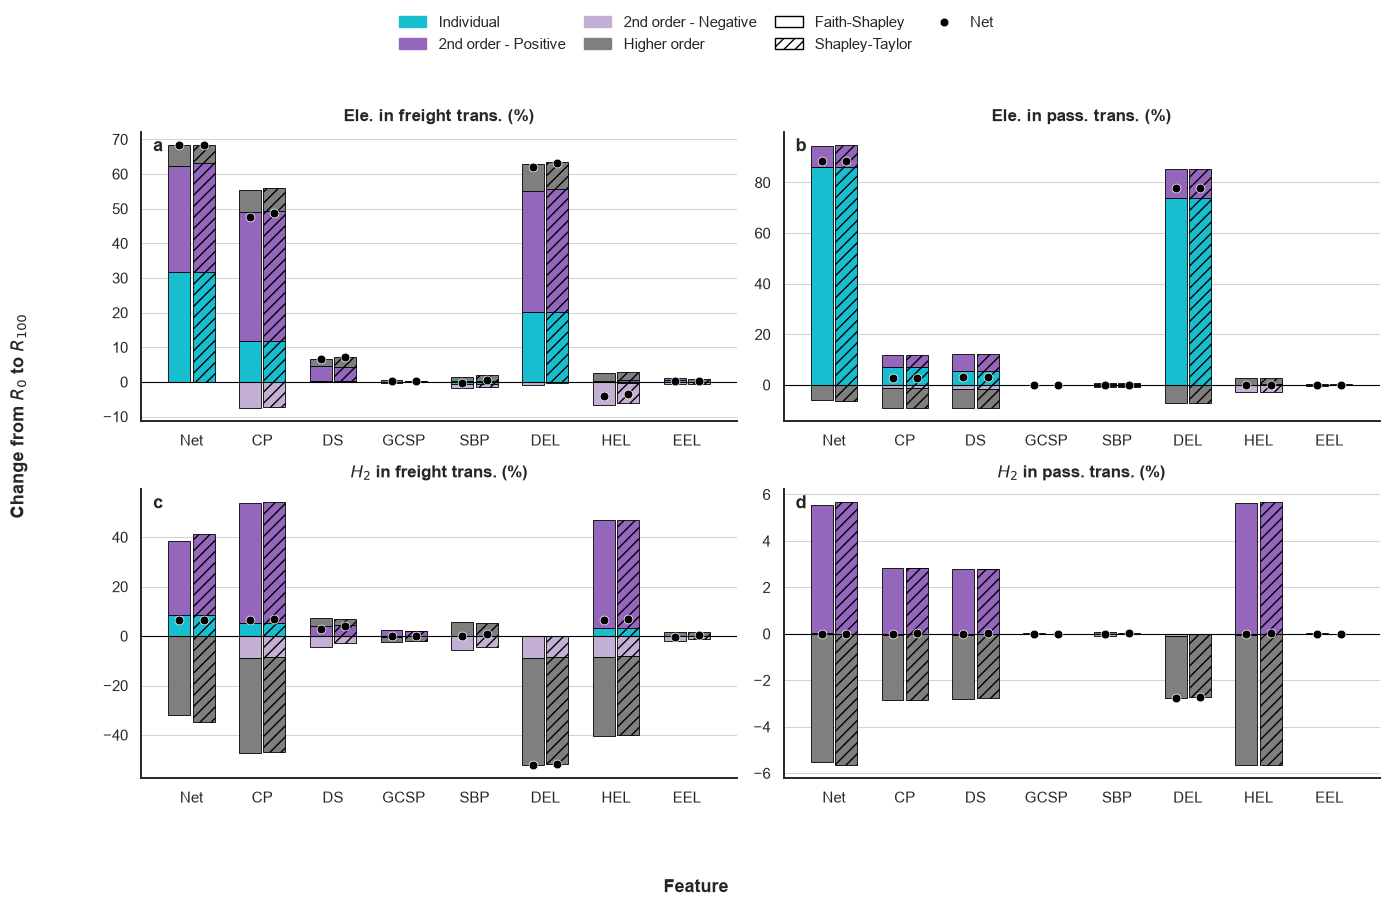

In [10]:
# Filter data
indicators = ['RFTRADELsh', 'RPTRADELsh', 'RFTRAHELsh', 'RPTRAHELsh']
regions = ['World']
cstep = '0-100'
methods = ['Shapley-Taylor', 'Faith-Shapley']
mode = 'absolute'
ims = indices_simple[
    (indices_simple['method'].isin(methods)) &\
    (indices_simple['mode']==mode)  &\
    (indices_simple['Region'].isin(regions)) &\
    (indices_simple['Indicator'].isin(indicators)) &\
    (indices_simple['ClimateStep']==cstep)]
ims.drop(columns=['Abs(Contribution)', 'mode'], inplace=True)

# Assign sectors and pathways
ims['Sector'] = None
ims.loc[ims['Indicator'].str.startswith('FIN'), 'Sector'] = 'Total final'
ims.loc[ims['Indicator'].str.startswith('TRA'), 'Sector'] = 'Transport'
ims.loc[ims['Indicator'].str.startswith('IND'), 'Sector'] = 'Industry'
ims.loc[ims['Indicator'].str.startswith('BLG'), 'Sector'] = 'Buildings'
ims['Pathway'] = None
ims.loc[ims['Indicator'].str.endswith('TELsh'), 'Pathway'] = 'Total elec.'
ims.loc[ims['Indicator'].str.endswith('DELsh'), 'Pathway'] = 'Direct elec.'
ims.loc[ims['Indicator'].str.endswith('HELsh'), 'Pathway'] = '$H_{2}$ elec.'
ims.loc[ims['Indicator'].str.endswith('SELsh'), 'Pathway'] = 'Efuels elec.'

# Define labels, sort data, and define layout and style
labels = {'RFTRADELsh': 'Ele. in freight trans. (%)',
          'RPTRADELsh': 'Ele. in pass. trans. (%)',
          'RFTRAHELsh': '$H_{2}$ in freight trans. (%)',
          'RPTRAHELsh': '$H_{2}$ in pass. trans. (%)',
          'Total': 'Net',}
methods = ['Shapley-Taylor', 'Faith-Shapley']
imsm = ims[ims['method'].isin(methods)]
coalitions = ['Total', 'CP', 'DS', 'GCSP', 'SBP', 'DEL', 'HEL', 'EEL']
effects = ['Individual', '2nd order - Positive', '2nd order - Negative', 'Higher order']
palette = {'Individual': colormaps['tab20'].colors[18],
           '2nd order - Positive': colormaps['tab20'].colors[8],
           '2nd order - Negative': colormaps['tab20'].colors[9],
           'Higher order': colormaps['tab20'].colors[14],
           'Total': colormaps['tab20'].colors[10]}

# Sort data
custom_sort = {'Individual': 0,
               '2nd order - Positive': 1,
               '2nd order - Negative': 2,
               'Higher order': 3,
               'Total': 4}
imsm.sort_values(by='effect',
                 key=lambda x: x.map(custom_sort),
                 inplace=True) 

# Define encodings, layout, and style
encode = pt.encodings.allocations(
    x='coalition',
    y='Contribution',
    color='effect',
    compare='method',
    category_orders={'coalition': coalitions,
                    'Indicator': indicators},
    color_order=effects,
    labels=labels,
    facet_col='Indicator')
y_title = r'Change from $R_{0}$ to $R_{100}$'
style = pt.Style(palette=palette,
                 reverse_palette=True,)
layout = pt.Layout(x_title='Feature',
                   y_title=y_title,
                   x_title_offset=0,
                   col_wrap=2,
                   share_y=False,
                   panel_letters=True)
                   
# Plot
pt.plot_allocations(imsm,
                    encode,
                    backend='matplotlib',
                    scatter_category={'effect': 'Total'},
                    layout=layout,
                    style=style
                    );

**Decomposition of the change in the share of electricity and $H_{2}$ by transport activity, between $R_{0}$ and $R_{100}$, in 2050, World.** Each stacked bar represents, the decomposition of the change in energy-related $CO_{2}$ emissions, summed over interaction orders (first, second positive, second negative, higher), irrespectively of the involved features. The net effect is shown as black dots. For each sector and pathway, the Shapley-Taylor (plain) and Faithful-Shapley (hatched) decompositions are presented.

# Figure 10
<a id="figure-10"></a>
## Carbon Capture, Utilization and Storage

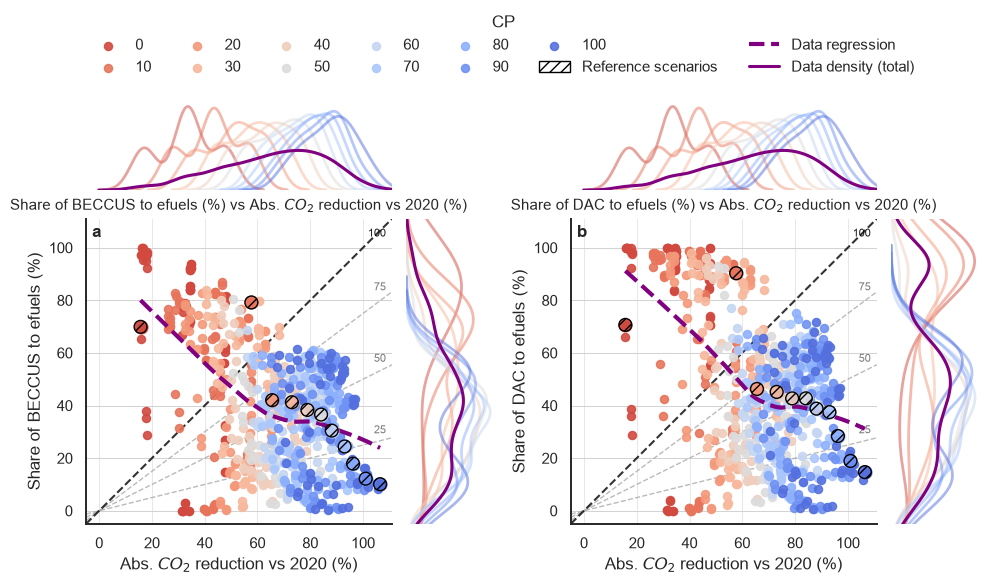

In [11]:
# Filter data and compute absolute emissions
dataw2050['EMITOTchab'] = dataw2050['EMITOTch'].abs()
ar6['EMITOTchab'] = ar6['EMITOTch'].abs()

# Define variable names and pairs
var_names = {'CO2CAPBIOinEFUsh': 'Share of BECCUS to efuels (%)',
             'CO2CAPDACinEFUsh': 'Share of DAC to efuels (%)',
             'EMITOTchab': 'Abs. $CO_{2}$ reduction vs 2020 (%)',
             'ClimatePolicy': 'Stringency of Global Climate Policy',
             'benchmark': 'AR6 benchmark',
             'LOESS (benchmark)': 'AR6 regression',
             'LOESS (data)': 'Data regression',
             'total': 'Data density (total)',
             'Highlight': 'Reference scenarios'}

var_pairs = [('EMITOTchab', 'CO2CAPBIOinEFUsh'), ('EMITOTchab', 'CO2CAPDACinEFUsh')]

# Sort data by Climate Policy
dataw2050 = dataw2050.sort_values(by=['CP'])

# Define encodings, style, regression, and layout
jointencoding = pt.encodings.joint(
  var_pairs=var_pairs,
  color='CP',
  category_orders={'CP': list(range(0, 101, 10))},
  labels=var_names)
style = pt.Style(
  palette='coolwarm',
  reverse_palette=True)
regression = pt.Regression(
  data=True,
  data_color='purple')
highlight = {'Case': [65, 192, 256, 320, 384, 448,
                      512, 576, 640, 704, 64]}
layout = pt.Layout(panel_letters=True)
pt.multi_jointplot_subfig(
  dataw2050,
  jointencoding,
  style=style,
  regression=regression,
  highlight=highlight,
  diag_quartiles=True,
  marginal_show_total=True,
  marginal_total_color='purple',
  symmetric_xy=True,
  layout=layout
);

**Emissions reductions and carbon utilization in 2050, World.** Each graph represents the scenarios produced in this study, with a color code corresponding to the level of carbon pricing (red to blue, from lowest to highest), and expressed as a percentage between the lowest (0%) and highest (100%) carbon price. The $R_{c}$ reference scenarios for each carbon price category are hatched and black-circled. Each quadrant further shows four $\alpha-$reference lines, indicated 25, 50, 75 and 100, representing the $y=\frac{\alpha}{100}x$ coordinates. Marginal distributions for the overall benchmark set, the overall set for this study, and each group of climate policy, are represented for each graph along the x and y axis. **a** Share of energy-related $CO_{2}$ emissions (x-axis, %) against share of $CO_{2}$ captured from biomass used in efuels production (y-axis, %). **b** Share of energy-related $CO_{2}$ emissions (x-axis, %) against share of $CO_{2}$ captured from DAC used in efuels production (y-axis, %).

# Figure 11
<a id="figure-11"></a>

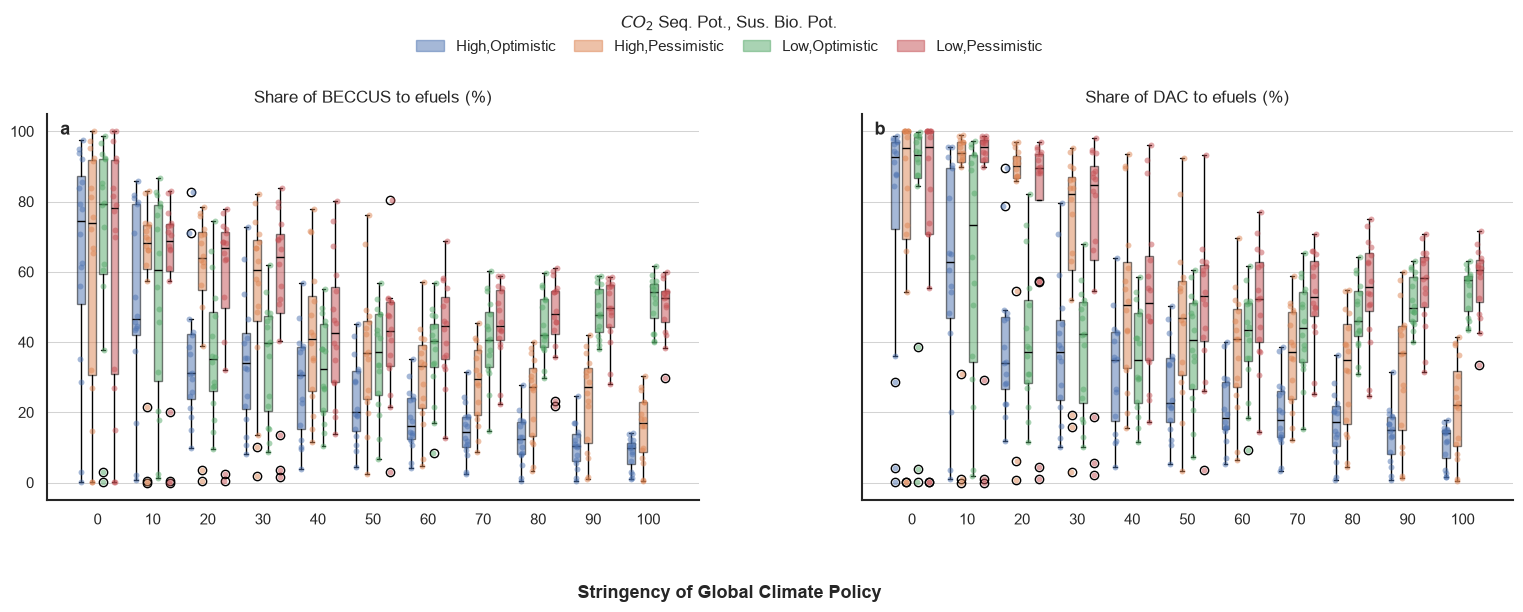

In [12]:
# Filter data and aggregate columns
ccbalance = dataw2050[['Case', 'CP', 'GCSP',
                       'SBP', 'CO2CAPBIOinEFUsh', 'CO2CAPDACinEFUsh']]
ccbalance.replace({'L-Med': 'High'}, inplace=True)
ccbalance['GCSP,SBP'] = ccbalance['GCSP'] + ',' + ccbalance['SBP']

# Define variable names
var_names = {'CO2CAPBIOinEFUsh': 'Share of BECCUS to efuels (%)',
             'CO2CAPDACinEFUsh': 'Share of DAC to efuels (%)',
             "GCSP,SBP": '$CO_{2}$ Seq. Pot., Sus. Bio. Pot.',
             'CP': 'Stringency of Global Climate Policy'}

# Define encodings, layout, and style
e = pt.encodings.box(x="CP", y=['CO2CAPBIOinEFUsh', 'CO2CAPDACinEFUsh'],
                     color="GCSP,SBP", labels=var_names)
layout = pt.Layout(panel_letters=True, share_y=True, wspace=0.25)
style=pt.Style(show_points=True,
               point_size=18,
               point_alpha=0.5,
               point_jitter=0.25,
               point_color=None)

# Plot
pt.grouped_boxplot(ccbalance, e, show_total=False,
                   layout=layout, style=style
                   );

**Shares of biogenic and atmospheric carbon used for efuels production in 2050, World.** Each graph represents the shares of biogenic (**a**) or atmospheric (**b**) carbon captured that are routed to efuels production, for each carbon price scenario. Each bar represent a combination of assumptions (Low/High or Pessimistic/Optimistic) for geological sequestration potential or sustainable biomass potential.

# Figure 12 & 13
<a id="figure-12-13"></a>
## Coalition-level interactions

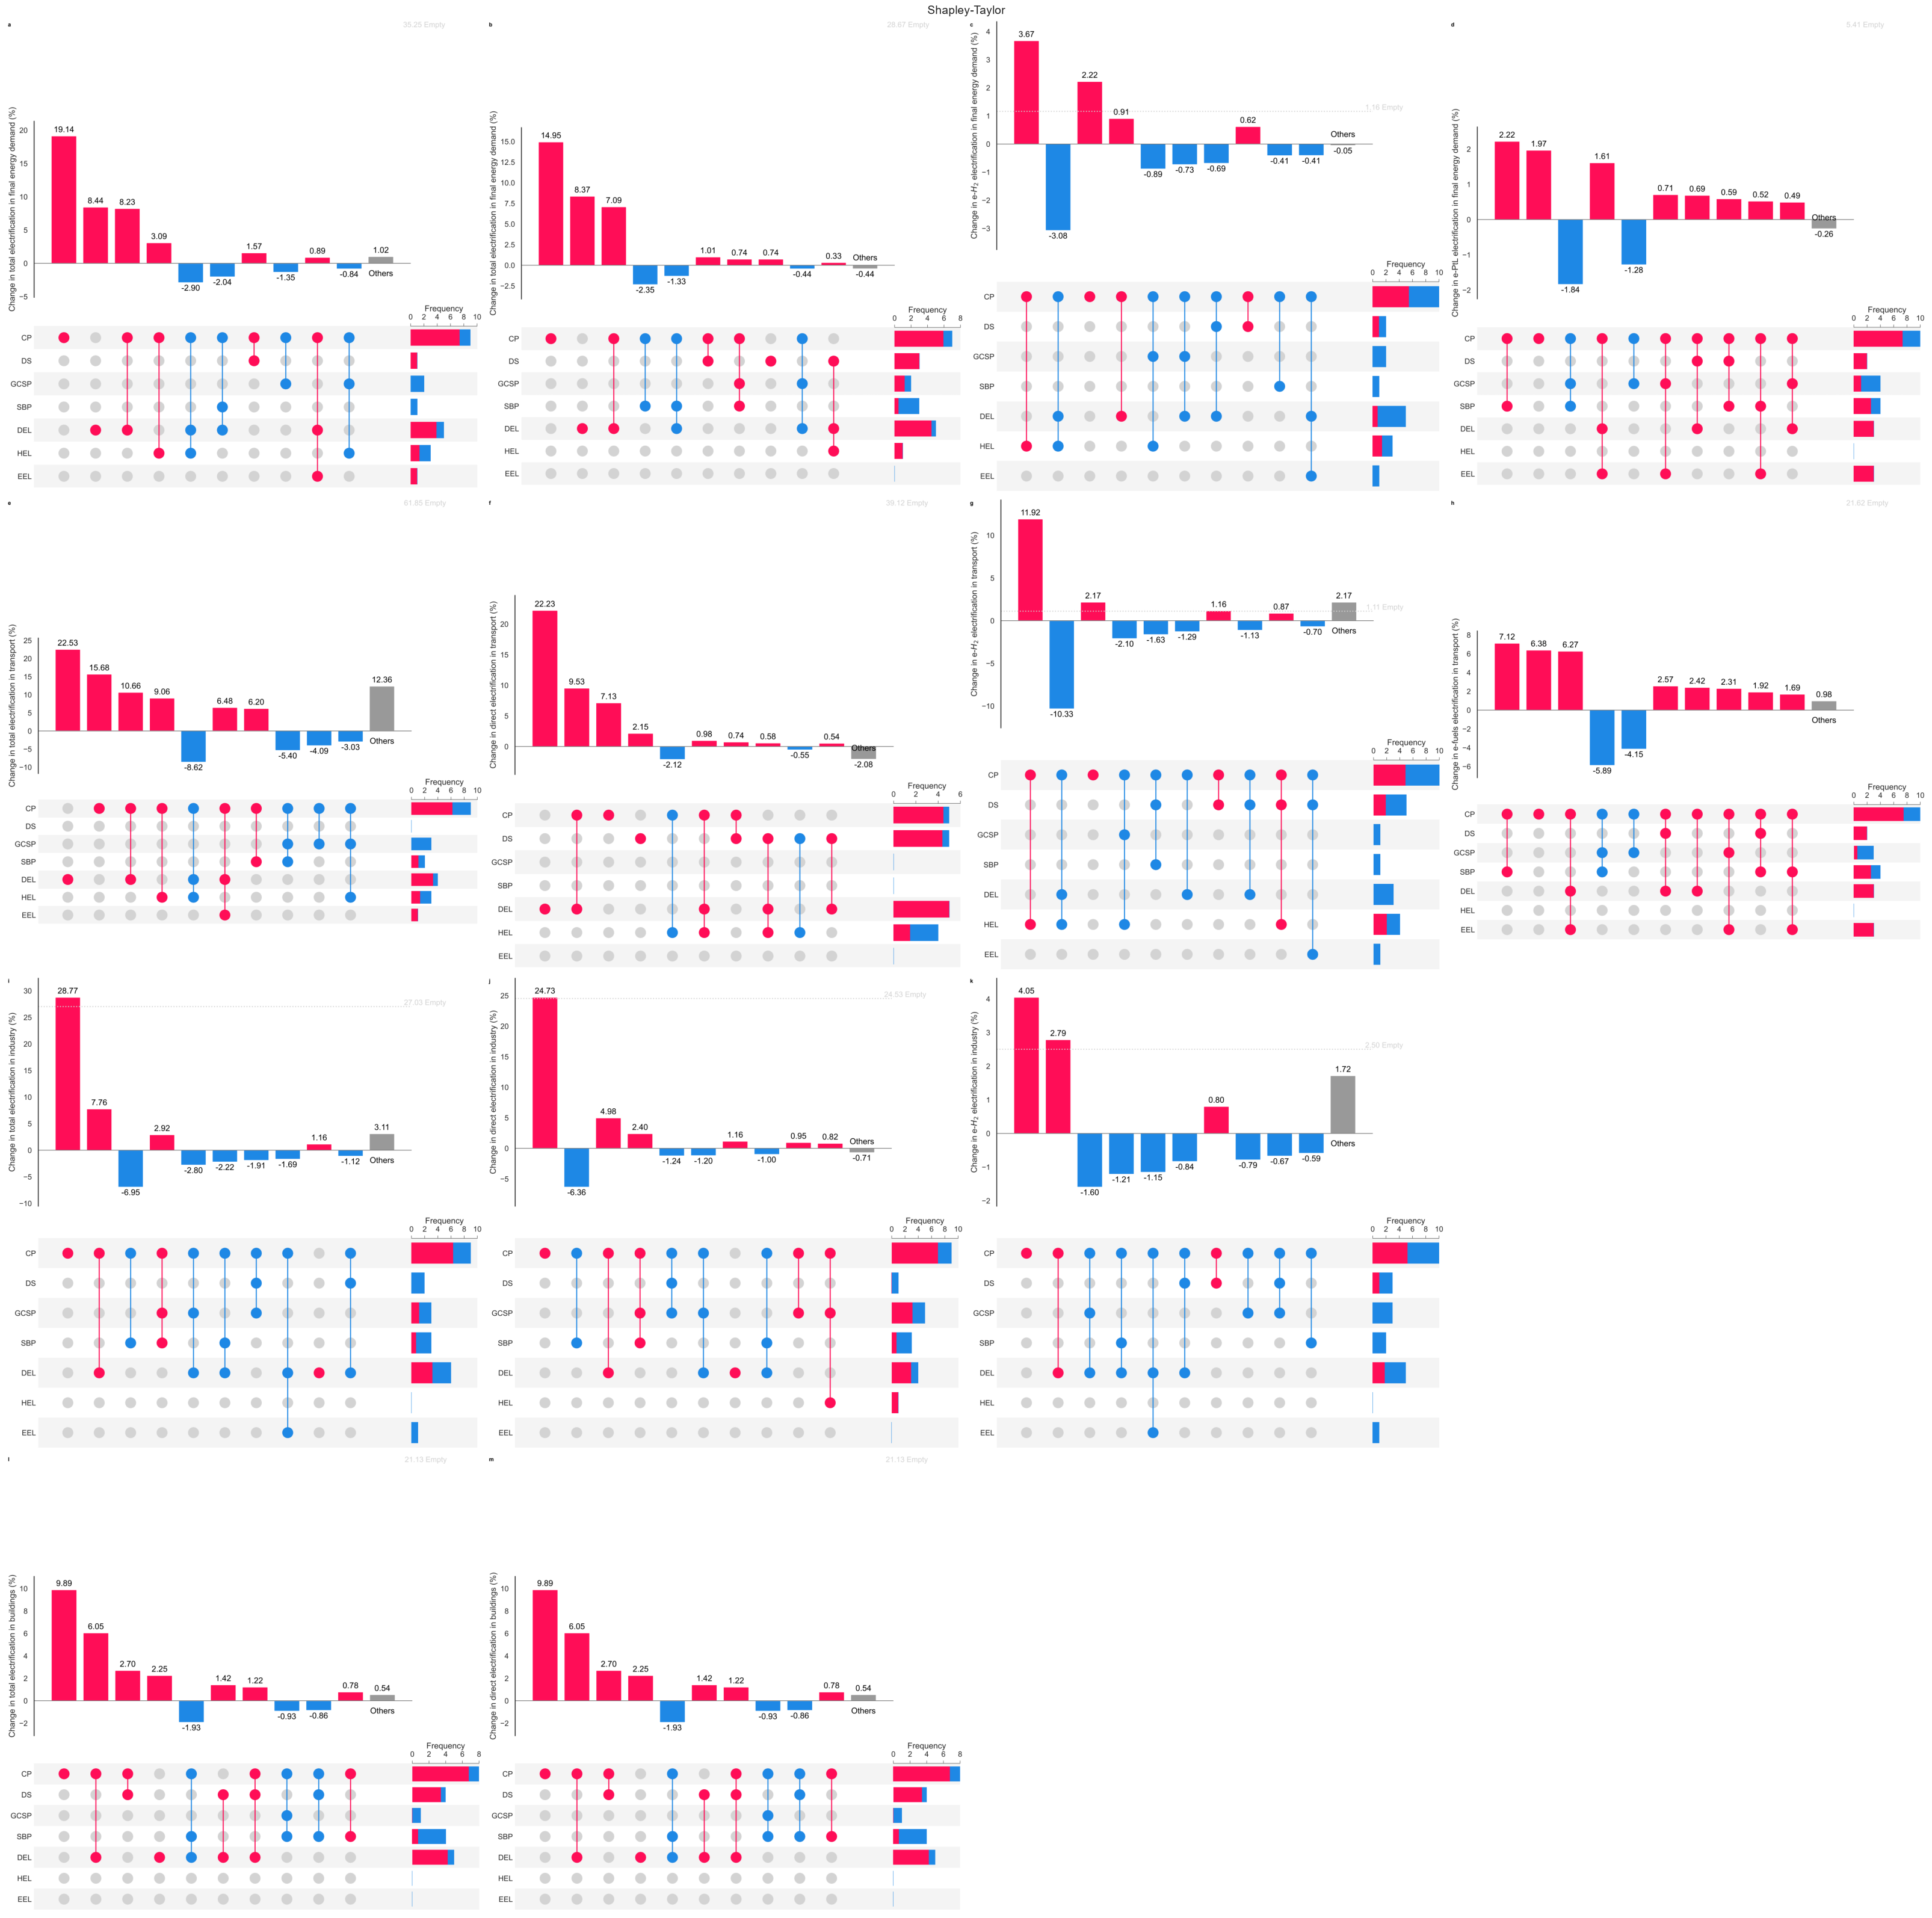

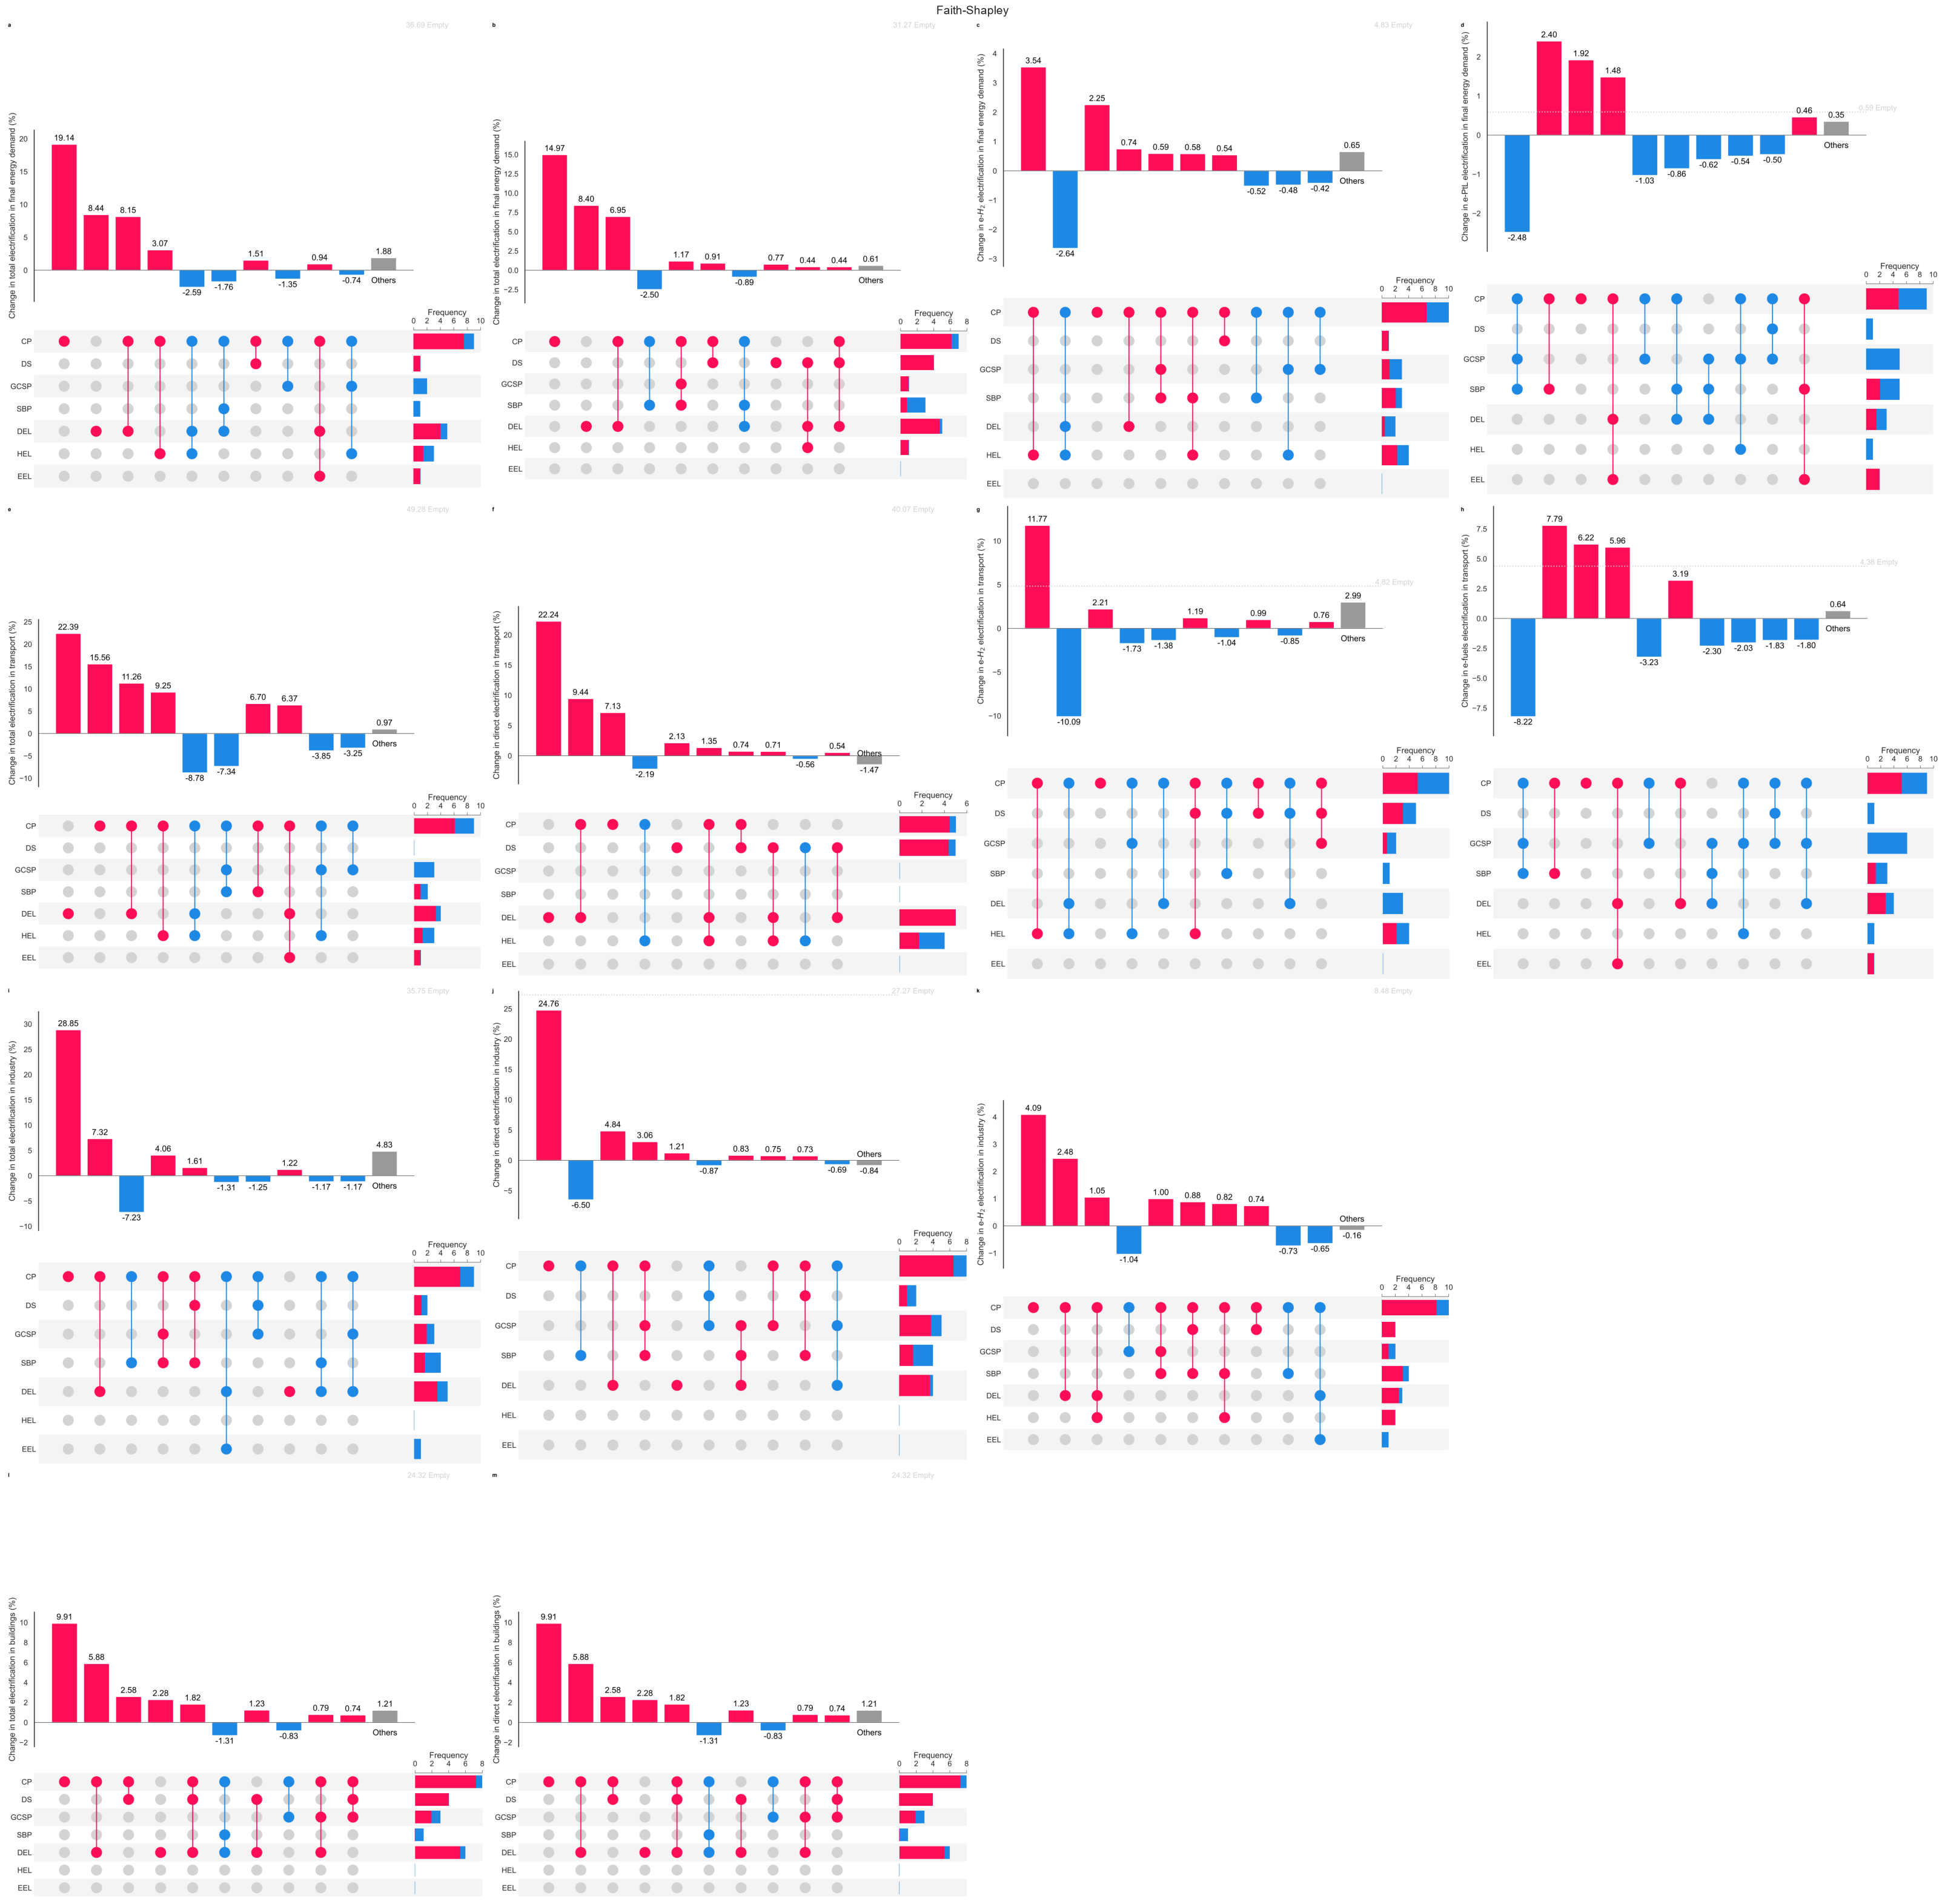

In [13]:
# Indicators and global parameters
indicators = list(
    dict.fromkeys([
        "ELETOT", "FINELC", "H2GELC", "FINHH2E",
        "AFUTOT", "AFUPtXE", "FINTELsh", "FINDELsh",
        "FINHELsh", "FINSELsh", "TRATELsh", "TRADELsh",
        "TRAHELsh", "TRASELsh", "INDTELsh", "INDDELsh",
        "INDHELsh", "BLGTELsh", "BLGDELsh", "EMITOT",
        "RFTRADELsh", "RPTRADELsh", "RFTRAHELsh",
        "RPTRAHELsh", "CO2CAPBIOinEFUsh",
        "CO2CAPDACinEFUsh"])
)

cstep = "0-100"
methods = ["Shapley-Taylor", "Faith-Shapley"]
mode = "absolute"
period = 2050
region = "World"
max_order = 3
n_interactions = 10
feats = ["CP", "DS", "GCSP", "SBP", "DEL", "HEL", "EEL"]
coalitions = list(indices["coalition"].unique())

names = {
    "TRATELsh": "Change in total electrification in transport (%)",
    "BLGTELsh": "Change in total electrification in buildings (%)",
    "TRASELsh": "Change in e-fuels electrification in transport (%)",
    "RFTRADELsh": (
        "Change in direct electrification in road freight transport (%)"
    ),
    "TRADELsh": "Change in direct electrification in transport (%)",
    "INDDELsh": "Change in direct electrification in industry (%)",
    "AFUTOT": "Change in total alternative liquid fuels generation (EJ)",
    "FINDELsh": "Change in total electrification in final energy demand (%)",
    "RPTRAHELsh": (
        r"Change in e-$H_{2}$ electrification in passenger road transport (%)"
    ),
    "H2GELC": r"Change in e-$H_{2}$ supply (EJ)",
    "INDTELsh": "Change in total electrification in industry (%)",
    "FINTELsh": "Change in total electrification in final energy demand (%)",
    "RPTRADELsh": (
        "Change in direct electrification in passenger road transport (%)"
    ),
    "ELETOT": "Change in total electricity supply (EJ)",
    "CO2CAPDACinEFUsh": (
        r"Change in the share of $CO_{2}$ captured from DAC used in e-fuels (%)"
    ),
    "FINSELsh": "Change in e-PtL electrification in final energy demand (%)",
    "CO2CAPBIOinEFUsh": (
        r"Change in the share of $CO_{2}$ captured from BECC used in e-fuels"
        r" (%)"
    ),
    "FINHH2E": "Change in final electrolytic hydrogen demand (EJ)",
    "AFUPtXE": "Change in e-PtL supply (EJ)",
    "FINELC": "Change in final electricity demand (EJ)",
    "TRAHELsh": r"Change in e-$H_{2}$ electrification in transport (%)",
    "INDHELsh": r"Change in e-$H_{2}$ electrification in industry (%)",
    "FINHELsh": (
        r"Change in e-$H_{2}$ electrification in final energy demand (%)"
    ),
    "BLGDELsh": "Change in direct electrification in buildings (%)",
    "EMITOT": r"Change in energy-related $CO_{2}$ emissions (Gt$CO_{2}$)",
    "RFTRAHELsh": (
        r"Change in e-$H_{2}$ electrification in road freight transport (%)"
    ),
}

# Grid construction and merge
grid_cols = [
    "Indicator","ClimateStep",
    "method", "mode", "coalition",
    "Period", "Region",
]
combinations = list(
    it.product(
        indicators, [cstep], methods, [mode], coalitions, [period], [region]
    )
)
indicesshapiq = pd.DataFrame(combinations, columns=grid_cols).merge(
    indices, how="left", on=grid_cols
)
indicesshapiq["Contribution"] = indicesshapiq["Contribution"].fillna(0)
indicesshapiq["Abs(Contribution)"] = indicesshapiq["Contribution"].abs()

panel_matrix = [
    ["FINTELsh", "FINDELsh", "FINHELsh", "FINSELsh"],
    ["TRATELsh", "TRADELsh", "TRAHELsh", "TRASELsh"],
    ["INDTELsh", "INDDELsh", "INDHELsh"],
    ["BLGTELsh", "BLGDELsh"],
]

intermediate_html = []
final_images = {}

# Ephemeral folder for PDF exports and compositing
with tempfile.TemporaryDirectory() as tmp_dir_str:
    tmp_path = Path(tmp_dir_str)
    counts = {}

    # Intermediate plot generation
    for indicator, method in it.product(indicators, methods):
        try:
            mask = (
                (indicesshapiq["Indicator"] == indicator)
                & (indicesshapiq["ClimateStep"] == cstep)
                & (indicesshapiq["method"] == method)
                & (indicesshapiq["mode"] == mode)
                & (indicesshapiq["Period"] == period)
                & (indicesshapiq["Region"] == region)
                & (indicesshapiq["coalition"] != "Total")
                & (indicesshapiq["order"] <= max_order)
            )
            siq = indicesshapiq.loc[mask].reset_index(drop=True)

            if siq.empty:
                continue

            vals = siq["Contribution"].values
            ks = list(map(tuple, siq["keys"]))
            lookup = {k: i for i, k in enumerate(ks)}

            ivs = CeaInteractionValues(
                values=vals,
                index="FSII",
                max_order=siq["order"].max(),
                n_players=len(feats),
                min_order=0,
                baseline_value=vals.sum(),
                interaction_lookup=lookup,
                estimated=False,
            )

            plot_labels = {
                "count_label": "Frequency",
                "y_label": names.get(indicator, indicator),
                "remainder": "Others",
                "empty_coalition": "Empty",
                "grand_coalition": "All",
            }

            fig = ivs.plot_upset(
                n_interactions=n_interactions,
                feature_names=feats,
                color_matrix=True,
                show=False,
                hide_empty_coalition=True,
                hide_grand_coalition=True,
                show_remainder=True,
                show_counts="proportion",
                labels=plot_labels,
            )

            # Persist individual PDF on disk for compose_panels
            fig_path = tmp_path / f"{indicator}_{method}.pdf"
            fig.savefig(fig_path, format="pdf", bbox_inches="tight")
            counts[indicator, method] = str(fig_path)

            # Encode PNG in memory for the collapsed intermediate drawer
            buf = BytesIO()
            fig.savefig(buf, format="png", bbox_inches="tight")
            b64 = base64.b64encode(buf.getvalue()).decode("utf-8")
            buf.close()

            # # Uncomment the following block to display intermediate figures in a collapsible drawer
            # intermediate_html.append(f"""
            # <div style="margin-bottom: 25px; border-bottom: 1px solid #eee; padding-bottom: 15px;">
            #     <h4 style="margin: 0 0 10px 0; color: #333; font-family: sans-serif;">{indicator} — {method}</h4>
            #     <img src="data:image/png;base64,{b64}" style="max-width: 100%; height: auto;" />
            # </div>
            # """)

            plt.close(fig)

        except Exception:
            counts[indicator, method] = None

    # Multi-panel assembly per method
    for method in methods:
        panel_rows = [
            [counts[ind, method] for ind in row if counts.get((ind, method))]
            for row in panel_matrix
        ]
        panel_rows = [r for r in panel_rows if r]

        if panel_rows:
            composite_pdf = tmp_path / f"Electrification_{method}.pdf"
            # Prevent output from compose_panels
            with (
                contextlib.redirect_stdout(io.StringIO()),
                contextlib.redirect_stderr(io.StringIO())
                ):
                compose_panels(
                    panel_rows,
                    str(composite_pdf),
                    align=["left"] * len(panel_rows),
                )

            # Load PIL rendering into memory and release file lock before folder cleanup
            doc = pdfium.PdfDocument(str(composite_pdf))
            final_images[method] = doc[0].render(scale=2).to_pil()
            doc.close()

# # Uncomment the following block to display intermediate figures inside the collapsible drawer
# display(
#     HTML(f"""
# <details style="border: 1px solid #ddd; border-radius: 6px; padding: 10px; margin: 10px 0;">
#     <summary style="cursor: pointer; font-weight: 600; color: #0366d6;">
#         Clic to view ({len(intermediate_html)} intermediate graphics)
#     </summary>
#     <div style="margin-top: 15px; text-align: center; max-height: 850px; overflow-y: auto;">
#         {"".join(intermediate_html)}
#     </div>
# </details>
# """)
# )

# Standard display for final assembled panels
for method, img in final_images.items():
    fig_display, ax = plt.subplots(figsize=(32, 32), layout="constrained")
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(method, fontsize=14)
    plt.show()

# Other supporting results

## Figure 14
<a id="figure-14"></a>
### Direct electrification in transport throught the mitigation space

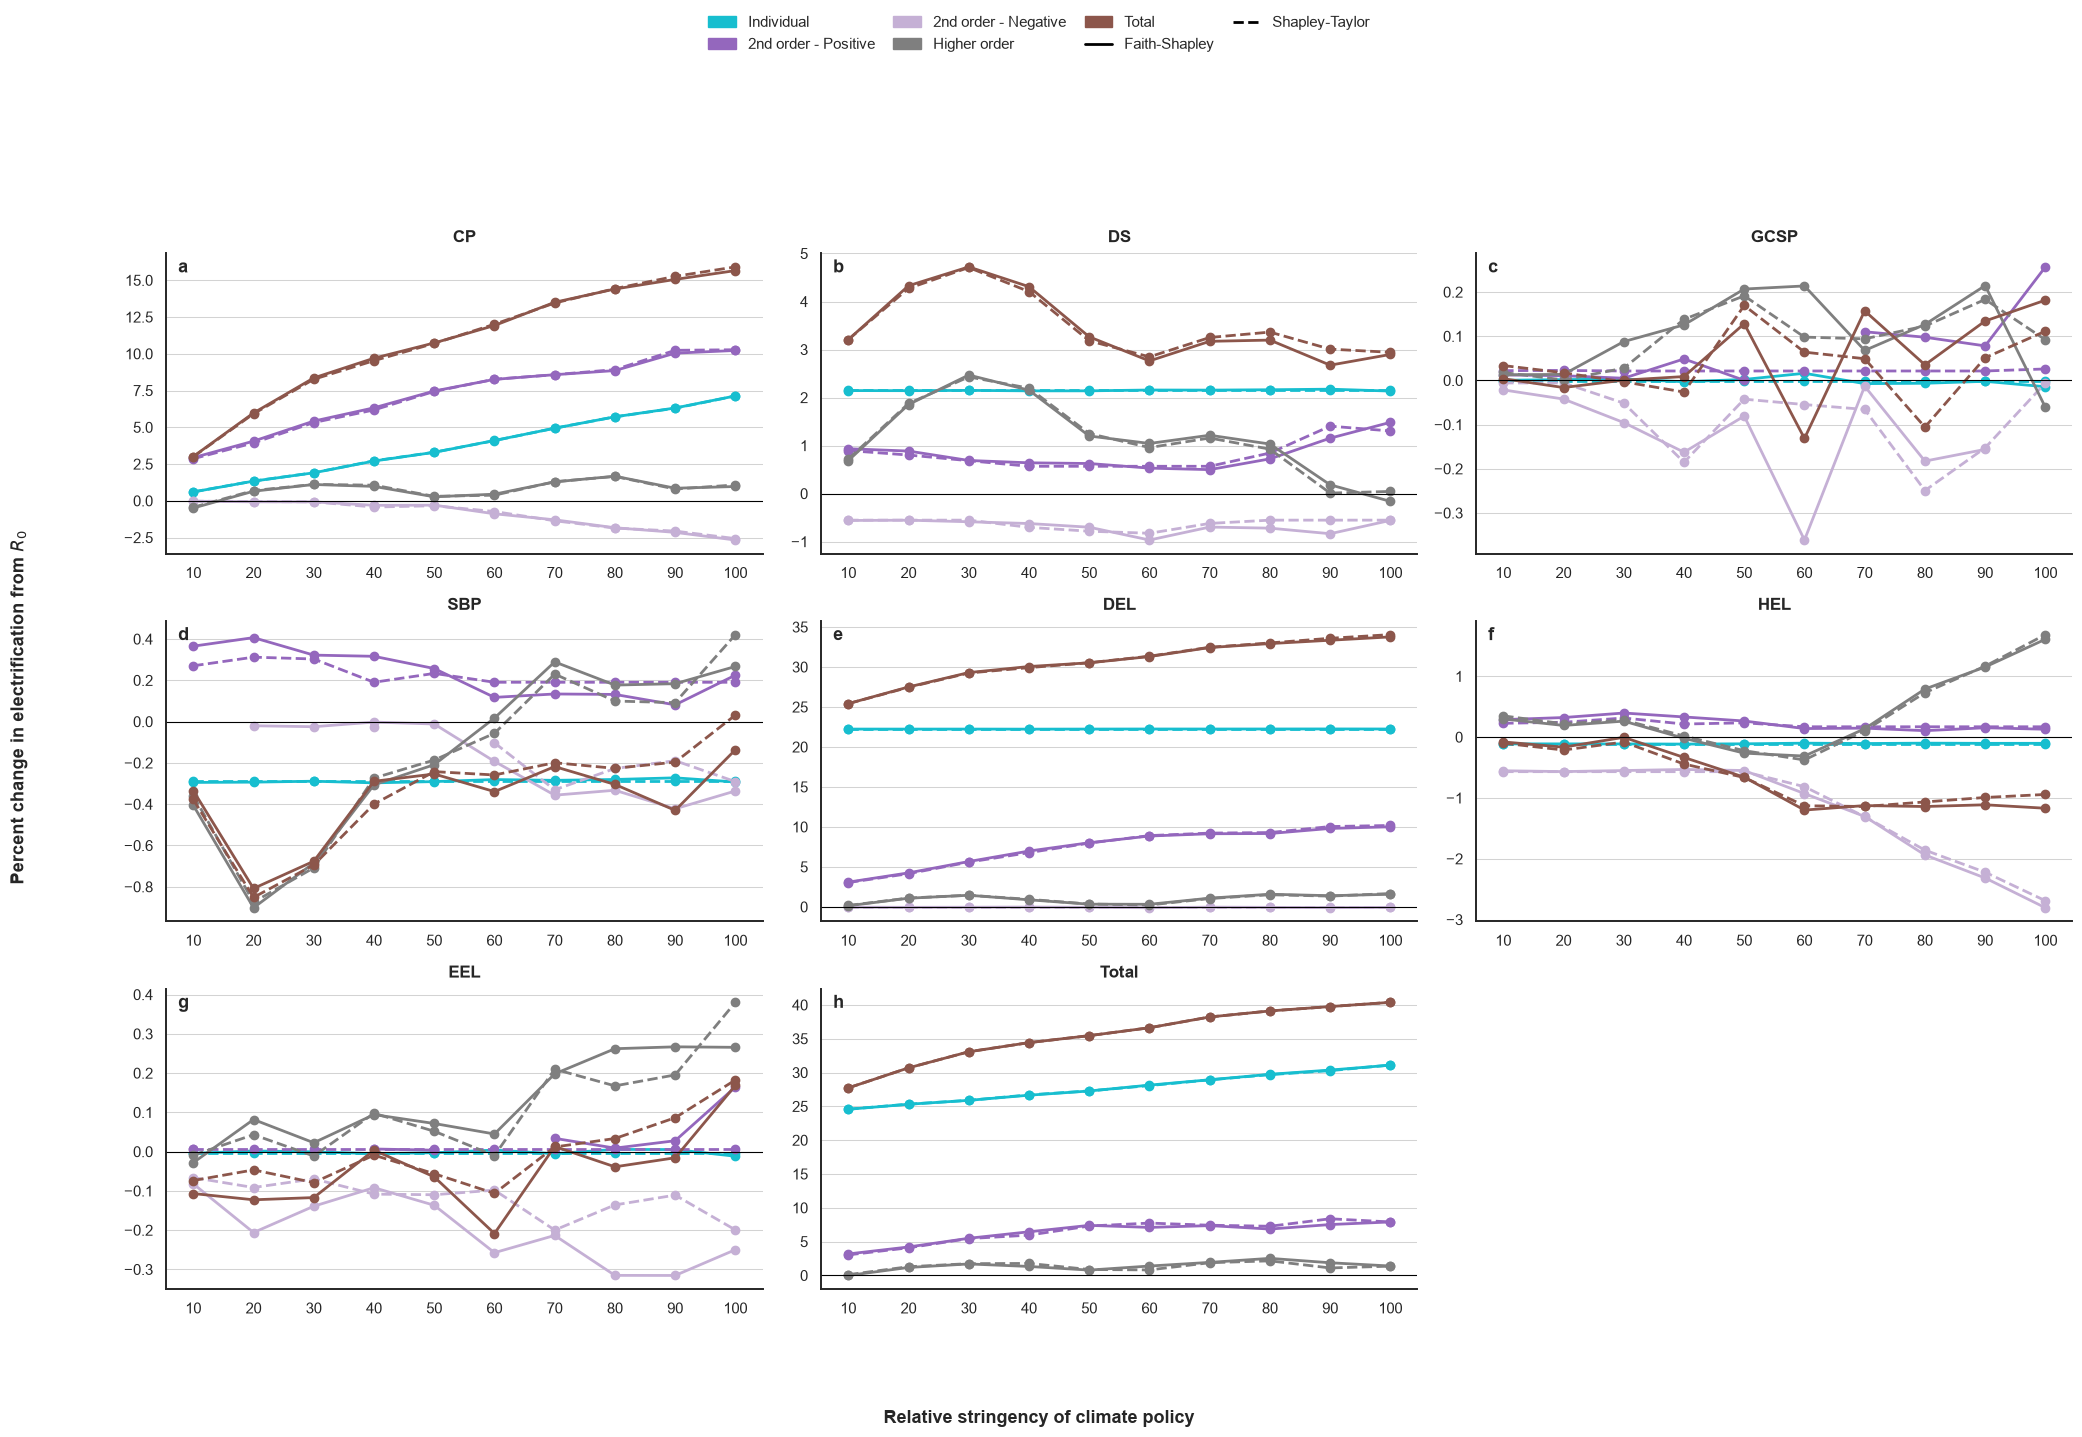

In [14]:
# Filter data
indicators = ['TRADELsh']
regions = ['World']
methods = ['Shapley-Taylor', 'Faith-Shapley']
mode = 'absolute'
ims = indices_simple[(indices_simple['method'].isin(methods)) & (indices_simple['mode']==mode)  &\
                     (indices_simple['Region'].isin(regions)) & (indices_simple['Indicator'].isin(indicators)) &\
                     (indices_simple['FromClimate']==0)]
ims.drop(columns=['Abs(Contribution)', 'mode'], inplace=True)

# Assign sectors and pathways
ims['Sector'] = None
ims.loc[ims['Indicator'].str.startswith('FIN'), 'Sector'] = 'Total final'
ims.loc[ims['Indicator'].str.startswith('TRA'), 'Sector'] = 'Transport'
ims.loc[ims['Indicator'].str.startswith('IND'), 'Sector'] = 'Industry'
ims.loc[ims['Indicator'].str.startswith('BLG'), 'Sector'] = 'Buildings'
ims['Pathway'] = None
ims.loc[ims['Indicator'].str.endswith('TELsh'), 'Pathway'] = 'Total elec.'
ims.loc[ims['Indicator'].str.endswith('DELsh'), 'Pathway'] = 'Direct elec.'
ims.loc[ims['Indicator'].str.endswith('HELsh'), 'Pathway'] = '$H_{2}$ elec.'
ims.loc[ims['Indicator'].str.endswith('SELsh'), 'Pathway'] = 'Efuels elec.'

# Define labels, sort data, and define layout and style
labels = {'TRADELsh': 'Direct', 'TRAHELsh': '$H_{2}$', 'TRASELsh': 'Efuels',
          'INDDELsh': 'Direct', 'INDHELsh': '$H_{2}$', 'BLGDELsh': 'Direct',
          'FINDELsh': 'Direct', 'FINHELsh': '$H_{2}$', 'FINSELsh': 'Efuels'}
methods = ['Shapley-Taylor', 'Faith-Shapley']
coalitions = ['CP', 'DS', 'GCSP', 'SBP', 'DEL', 'HEL', 'EEL', 'Total']
effects = ['Individual', '2nd order - Positive',
           '2nd order - Negative', 'Higher order', 'Total']
palette = {'Individual': colormaps['tab20'].colors[18],
           '2nd order - Positive': colormaps['tab20'].colors[8],
           '2nd order - Negative': colormaps['tab20'].colors[9],
           'Higher order': colormaps['tab20'].colors[14],
           'Total': colormaps['tab20'].colors[10]}

# Sort data
custom_sort = {'Individual': 0,
               '2nd order - Positive': 1,
               '2nd order - Negative': 2,
               'Higher order': 3,
               'Total': 4}
imsm.sort_values(by='effect',
                 key=lambda x: x.map(custom_sort),
                 inplace=True) 
imsm = ims[ims['coalition'].isin(coalitions)]

# Define encodings, layout, and style
encode = pt.encodings.allocations(x='ToClimate',
                                  y='Contribution',
                                  color='effect',
                                  compare='method',
                                  facet_col='coalition',
                                  category_orders={'coalition': coalitions,
                                                   'ToClimate': list(range(10,101,10))},
                                  color_order=effects,
                                  )
layout = pt.Layout(x_title='Relative stringency of climate policy',
                   y_title=r'Percent change in electrification from $R_{0}$',
                   x_title_offset=10,
                   legend_y=0.97,
                   col_wrap=3,
                   share_y=False,
                   panel_letters=True)
style = pt.Style(palette=palette,
                 reverse_palette=True,)

# Plot
pt.plot_allocations(imsm, encode,
                    graph_type='line',
                    backend='matplotlib',
                    layout=layout,
                    style=style,
                    show=True
                    );

**Explanation of the share of electricity in transport energy consumption across the mitigation space in 2050, World.** Each graph represents the decomposition of the contributions of each feature by order (y-axis), across the mitigation space, for each $R_{0}-R_{c}$ pair (x-axis). Shapley-Taylor and Faithful-Shapley methods are compared in plain and dashed lines. *Important remark*: each stacked bar group represents the effect *involving* each feature. Therefore, non-individual effects are reported for each feature involved; the bars, apart from the total, are not additive.

# Supply-side energy mix

## Figure 15
<a id="figure-15"></a>

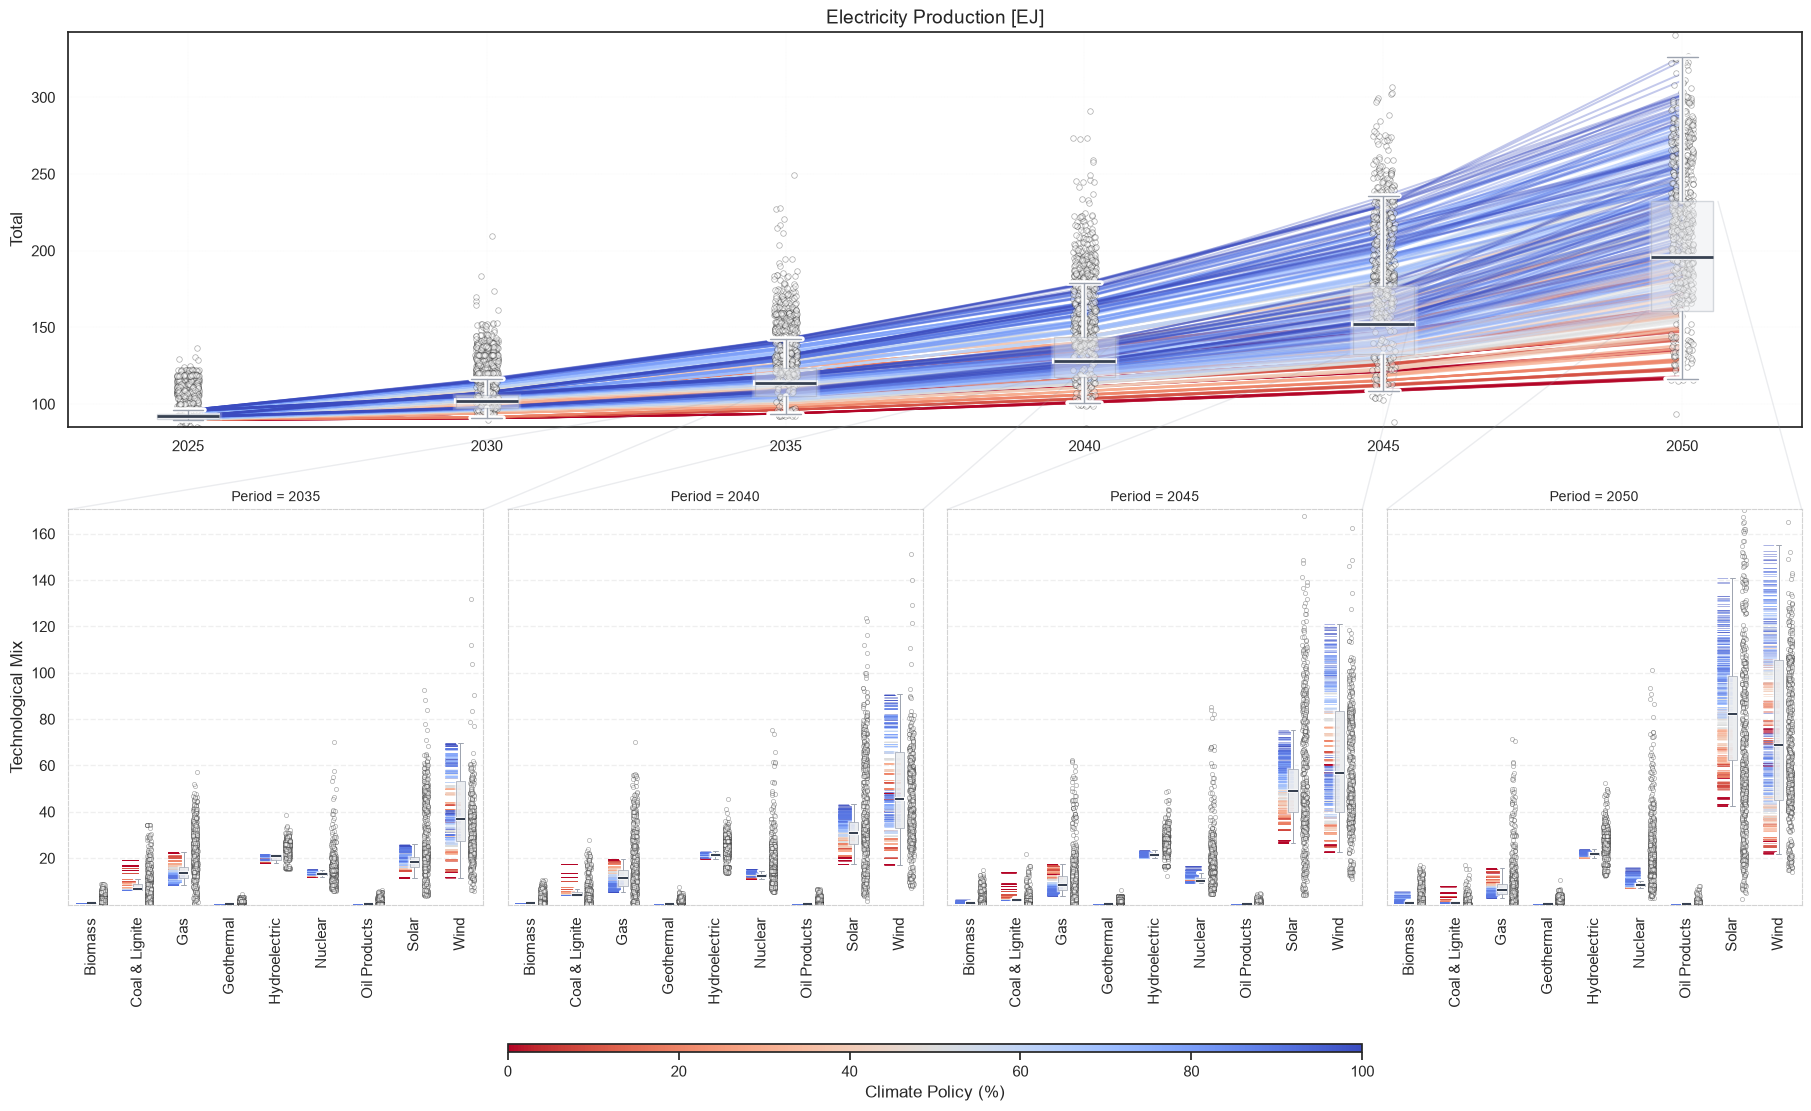

In [15]:
# Categorical columns
policy_levels = list(range(0,101,10))
categorical = {"ClimatePolicy": policy_levels}

# Define index columns and aggregating column names
index_col = ["Case","Region","Period","ClimatePolicy"]
aggregating_columns_names = {"Biomass": ["ELEBio","ELEBio-S"],
                    "Coal & Lignite" : ["ELECoal_Lignite","ELECoal_Lignite-S"],
                    "Gas":["ELEGas","ELEGas-S"],
                    "Geothermal":['ELEGeothermal'],
                    "Hydroelectric":['ELEHydro'],
                    "Nuclear":['ELENuclear'],
                    "Oil Products":['ELEOilProducts'],
                    "Solar":['ELESolar'],
                    "Wind":['ELEWind'],
                    "Total":['ELETOT']
                    }


# Filtering parameters
periods =  [2025, 2030, 2035, 2040, 2045, 2050]
ref_periods = [2025, 2030, 2035, 2040, 2045, 2050]
regions = [ "World"]
row_filters = {"Region": regions, "Period": periods}

# AR6 mapping
reference_index_col = ["Model","Region","Year","Scenario","Category"]
reference_aggregating_columns_names = {
    "Biomass": ['Secondary Energy|Electricity|Biomass|w/o CCS'],
    "Coal & Lignite" : ['Secondary Energy|Electricity|Coal|w/o CCS'],
    "Gas":['Secondary Energy|Electricity|Gas|w/o CCS'],
    "Geothermal":['Secondary Energy|Electricity|Geothermal'],
    "Hydroelectric":['Secondary Energy|Electricity|Hydro'],
    "Nuclear":['Secondary Energy|Electricity|Nuclear'],
    "Oil Products":['Secondary Energy|Electricity|Oil|w/o CCS'],
    "Solar":['Secondary Energy|Electricity|Solar'],
    "Wind":['Secondary Energy|Electricity|Wind'],
    "Total":["Secondary Energy|Electricity"]
    }

# Define reference row filters and NaN values
categories = ["C1","C2","C3","C4"]
reference_row_filters = {"Year": ref_periods, "Category": categories}
reference_nan_values = [0]

# Names
display = {
    'Grid': 'Period', 'Zoom Grid': [2035, 2040, 2045, 2050],
    'Yaxis': 'Electricity Production [EJ]', 'ColorStrip': "ClimatePolicy"}

options = {
    'rasterized': True
}

myplot = LineZoomHistGridPlot(
    data=data,
    index_col=index_col,
    row_filters=row_filters,
    col_names=aggregating_columns_names,
    reference_data=ar6,
    reference_index_col=reference_index_col,
    reference_row_filters=reference_row_filters,
    reference_col_names=reference_aggregating_columns_names,
    reference_nan_values=reference_nan_values,
    display=display,
    options=options
)

myplot.plot()
plt.show()

## Figure 16
<a id="figure-16"></a>

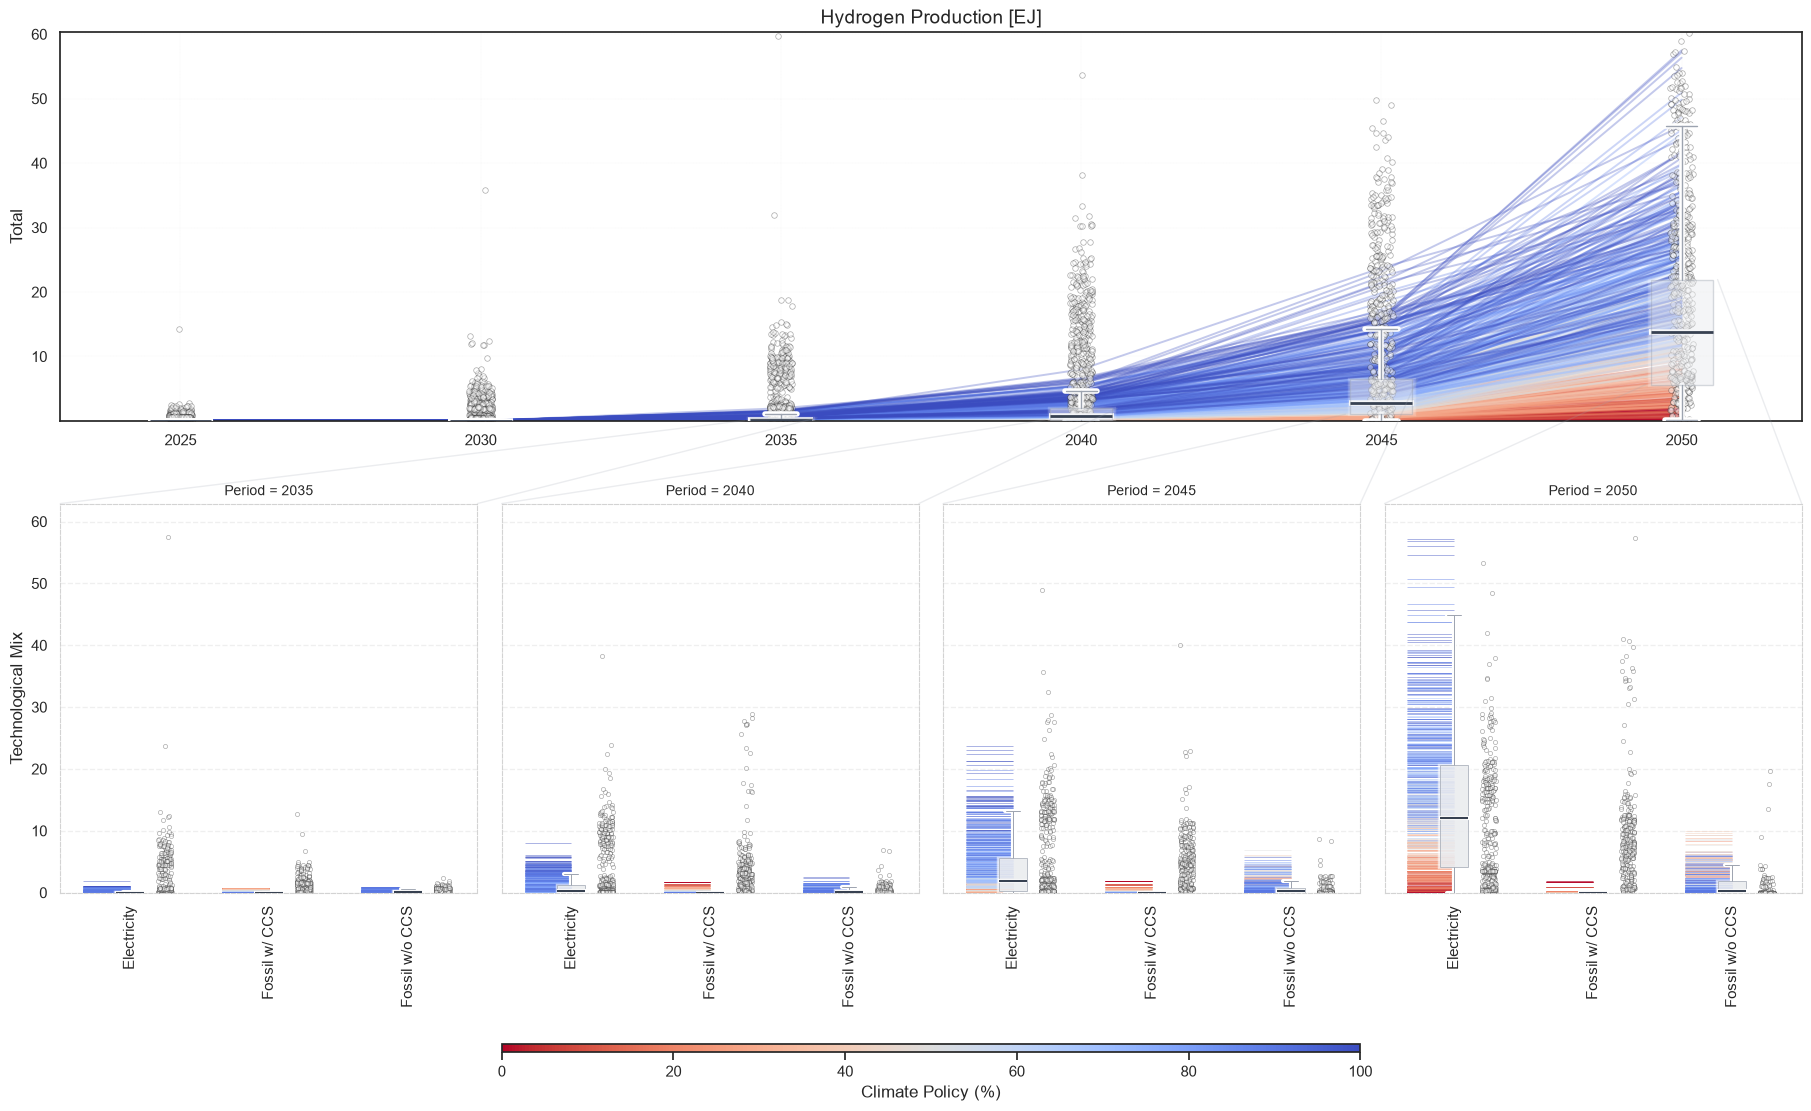

In [16]:
# Categorical columns
policy_levels = list(range(0,101,10))
categorical = {"ClimatePolicy": policy_levels}

# Define index columns and aggregating column names
index_col = ["Case","Region","Period","ClimatePolicy"]
aggregating_columns_names = {
    "Electricity": ["H2GELC"],
    "Fossil w/ CCS": ["H2GFos"],
    "Fossil w/o CCS": ["H2GFos_CCS"],
    "Total": ["H2GTOT"],
}

# Filtering parameters
periods =  [2025, 2030, 2035, 2040, 2045, 2050]
ref_periods = [2025, 2030, 2035, 2040, 2045, 2050]
regions = [ "World"]
row_filters = {"Region": regions, "Period": periods}

# AR6 mapping
reference_index_col = ["Model","Region","Year","Scenario","Category"]
reference_aggregating_columns_names = {
    "Electricity": ["Secondary Energy|Hydrogen|Electricity"],
    "Fossil w/ CCS": ["Secondary Energy|Hydrogen|Fossil|w/ CCS"],
    "Fossil w/o CCS": ["Secondary Energy|Hydrogen|Fossil|w/o CCS"],
    "Total": ["Secondary Energy|Hydrogen"],
}

# Define reference row filters and NaN values
categories = ["C1","C2","C3","C4"]
reference_row_filters = {"Year": ref_periods, "Category": categories}
reference_nan_values = [0]

# Names
display = {
    'Grid': 'Period', 'Zoom Grid': [2035, 2040, 2045, 2050],
    'Yaxis': "Hydrogen Production [EJ]", 'ColorStrip': "ClimatePolicy"
}

options = {
    'rasterized': True
}

myplot = LineZoomHistGridPlot(
    data=data,
    index_col=index_col,
    row_filters=row_filters,
    col_names=aggregating_columns_names,
    reference_data=ar6,
    reference_index_col=reference_index_col,
    reference_row_filters=reference_row_filters,
    reference_col_names=reference_aggregating_columns_names,
    reference_nan_values=reference_nan_values,
    display=display,
    options=options
)

myplot.plot()
plt.show()

## Figure 17
<a id="figure-17"></a>

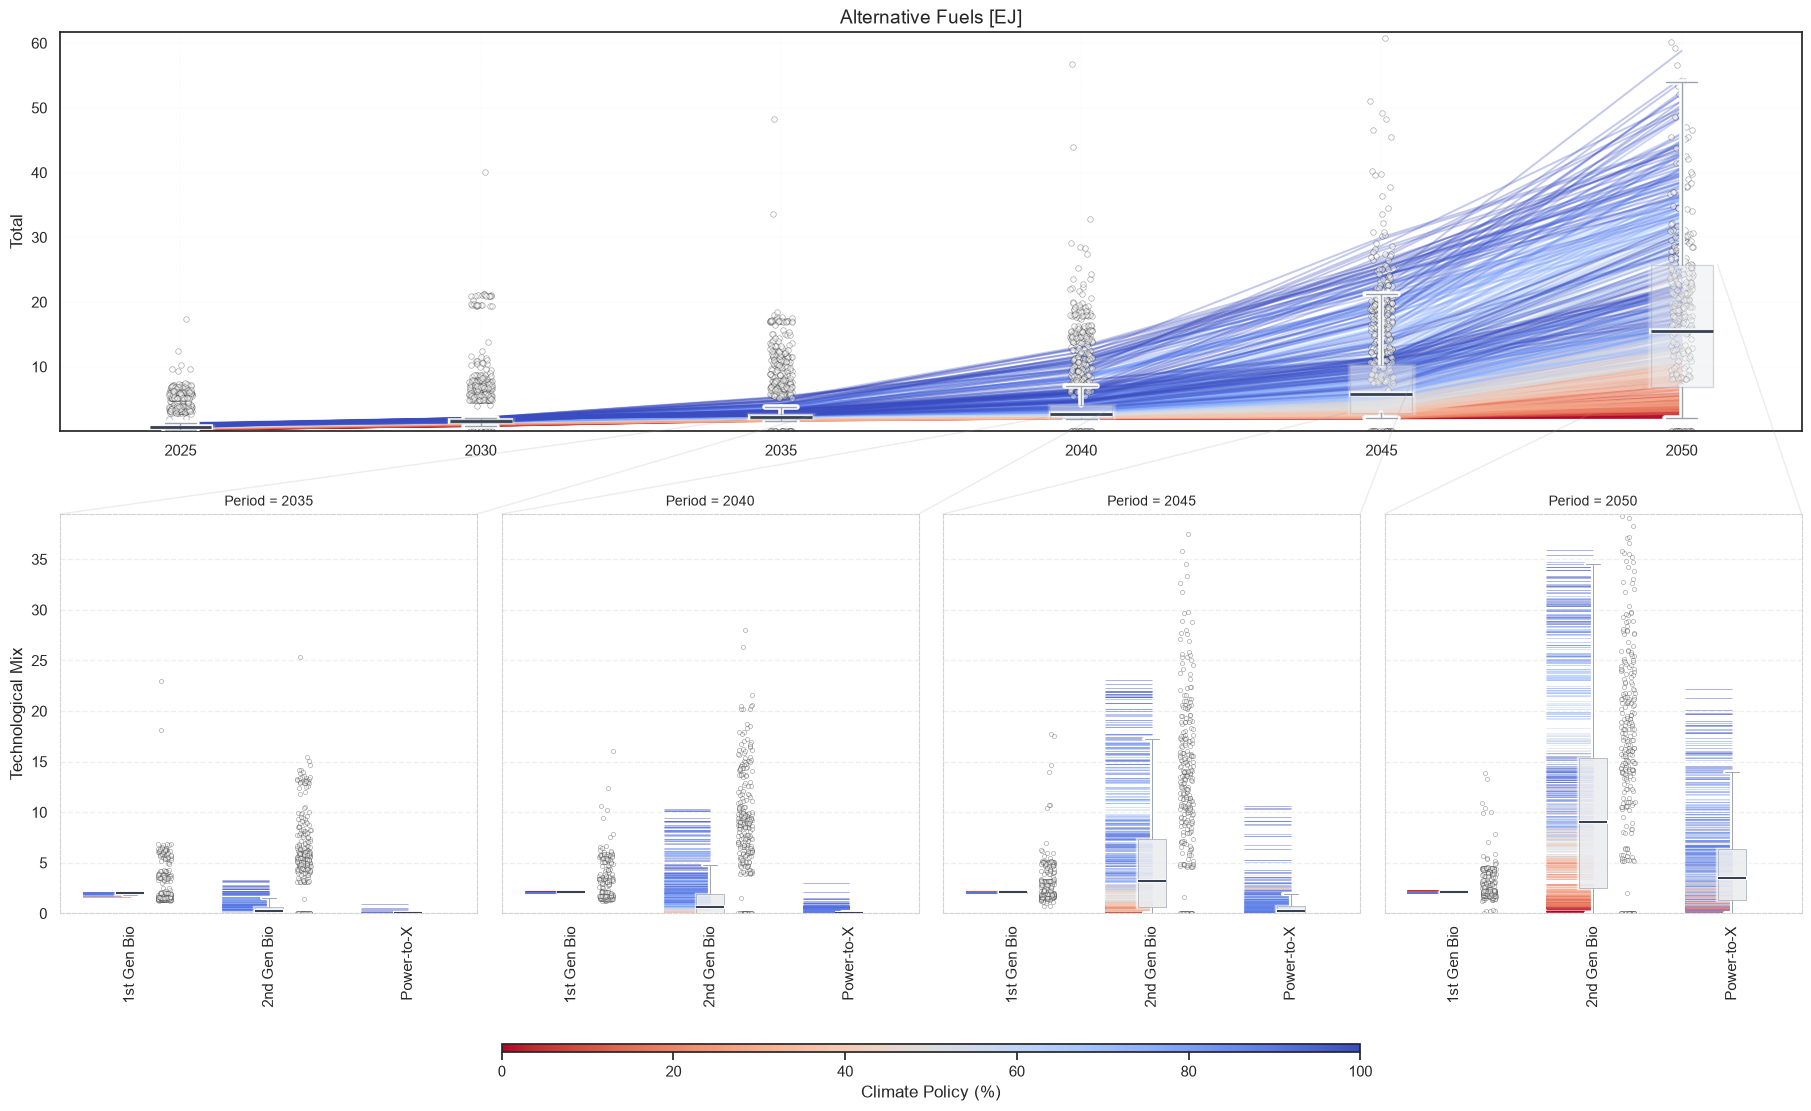

In [17]:
# Categorical columns
policy_levels = policy_levels = list(range(0,101,10))
categorical = {"ClimatePolicy": policy_levels}

# Define index columns and aggregating column names
index_col = ["Case","Region","Period","ClimatePolicy"]
aggregating_columns_names = {
    "1st Gen Bio": ["AFUG1"],
    "2nd Gen Bio": ["AFUG2"],
    "Power-to-X": ["AFUPtX"],
    "Total": ["AFUTOT"],
}

# Filtering parameters
periods =  [2025, 2030, 2035, 2040, 2045, 2050]
ref_periods = [2025, 2030, 2035, 2040, 2045, 2050]
regions = [ "World"]
row_filters = {"Region": regions, "Period": periods}

# AR6 mapping
reference_index_col = ["Model","Region","Year","Scenario","Category"]
reference_aggregating_columns_names = {
    "1st Gen Bio": ["Secondary Energy|Liquids|Biomass|1st Generation"],
    "2nd Gen Bio": [
        "Secondary Energy|Liquids|Biomass|Energy Crops",
        "Secondary Energy|Liquids|Biomass|Residues",
    ],
    "Power-to-X": [
        "Final Energy|Industry|Gases|Hydrogen synfuel",
        "Final Energy|Industry|Liquids|Hydrogen synfuel"
    ],
    "Total": [
        "1st Gen Bio",
        "2nd Gen Bio",
        "Power-to-X"
    ],
}

# Define reference row filters and NaN values
categories = ["C1","C2","C3","C4"]
reference_row_filters = {"Year": ref_periods, "Category": categories}
reference_nan_values = [0]

# Names
display = {
    'Grid': 'Period', 'Zoom Grid': [2035, 2040, 2045, 2050],
    'Yaxis': "Alternative Fuels [EJ]", 'ColorStrip': "ClimatePolicy"}

options = {
    'rasterized': True
}

myplot = LineZoomHistGridPlot(
    data=data,
    index_col=index_col,
    row_filters=row_filters,
    col_names=aggregating_columns_names,
    reference_data=ar6,
    reference_index_col=reference_index_col,
    reference_row_filters=reference_row_filters,
    reference_col_names=reference_aggregating_columns_names,
    reference_nan_values=reference_nan_values,
    display=display,
    options=options
)

myplot.plot()
plt.show()

# Demand-side energy mix

## Figure 18
<a id="figure-18"></a>

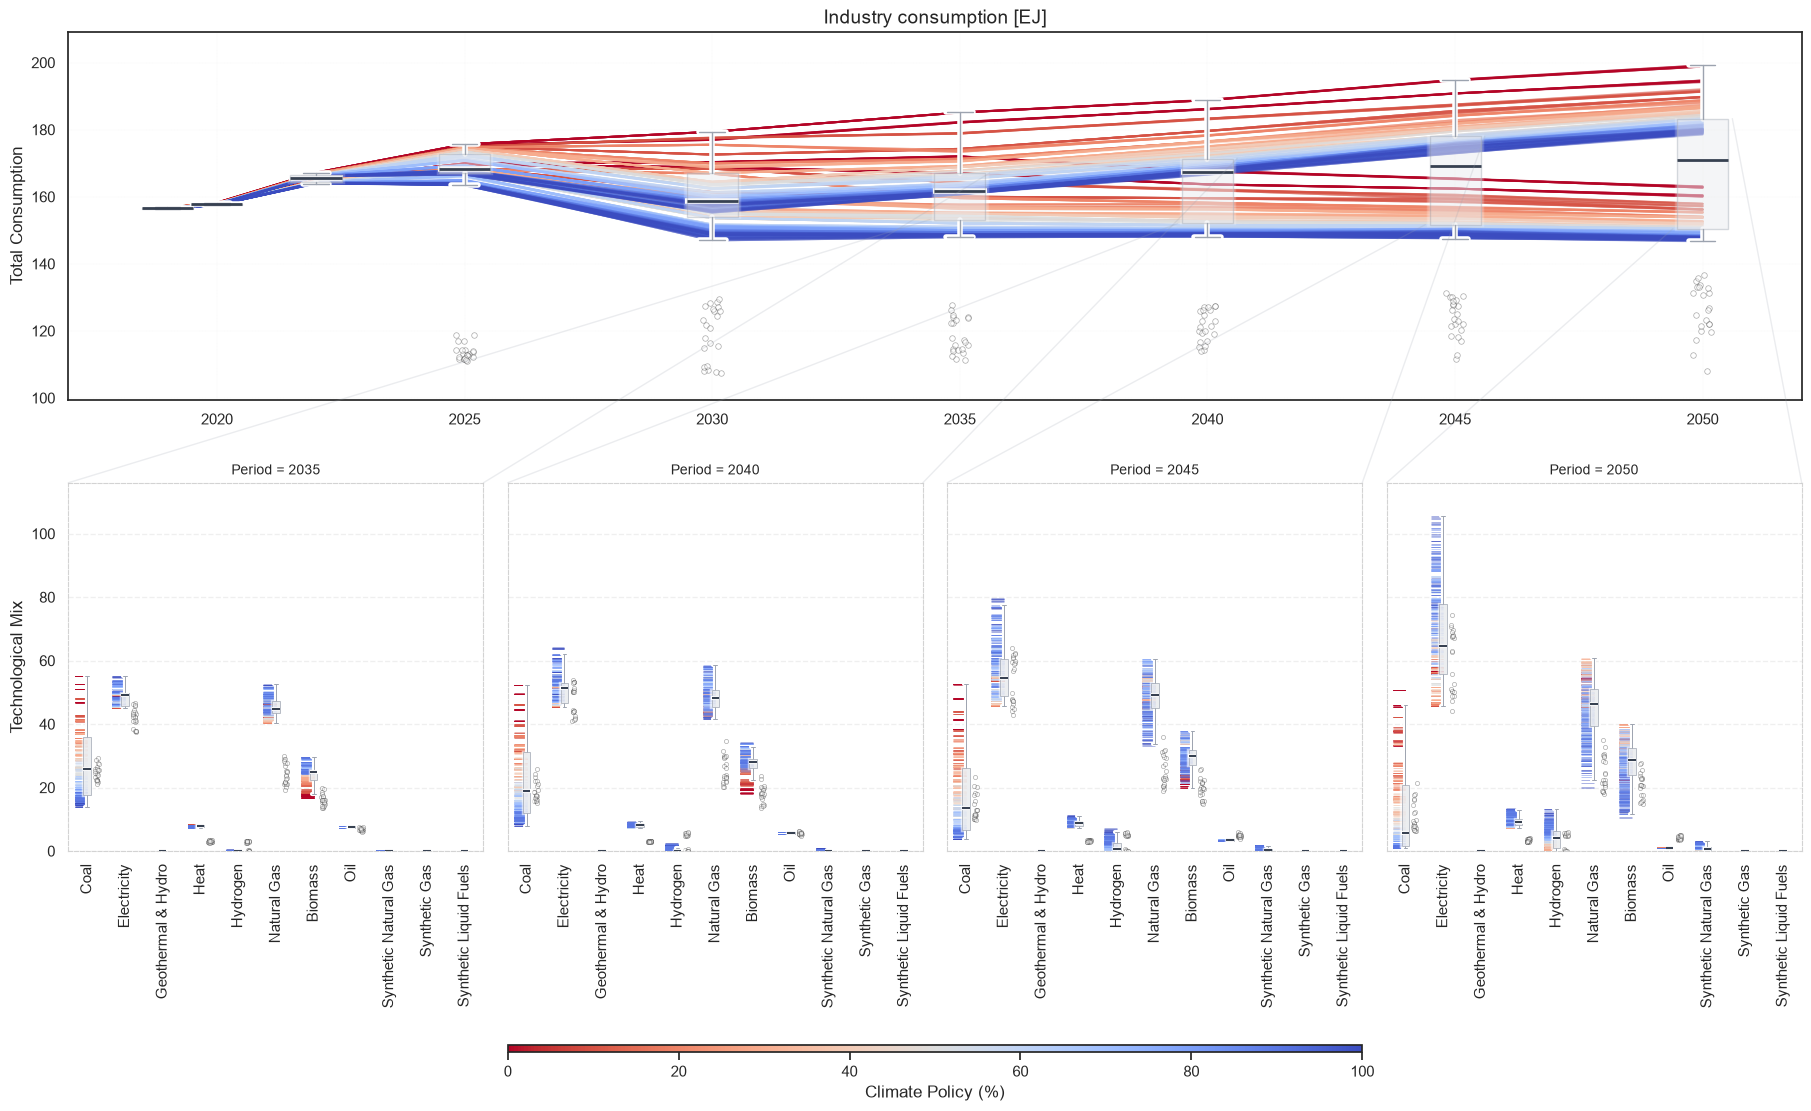

In [18]:
# Categorical columns
policy_levels = list(range(0,101,10))
categorical = {"ClimatePolicy": policy_levels}

# Define index columns and aggregating column names
index_col = ["Case","Region","Period","ClimatePolicy"]
aggregating_columns_names = {
    "Coal" : ["INDCOA"],
    "Electricity" : ["INDELC"],
    "Geothermal & Hydro" : ["INDGEO","INDHYD"],
    "Heat" : ["INDHET"],
    "Hydrogen" : ["INDHH2"],
    "Natural Gas" : ["INDNGA"],
    "Biomass" : ["INDBIO"],
    "Oil" : ["INDOIL"],
    "Synthetic Natural Gas" : ["INDSNG"],
    "Synthetic Gas" : ["INDSYG"],
    "Synthetic Liquid Fuels" : ["INDSYL"],
    "Total Consumption": ["INDTOT"]}

# Filtering parameters
periods =  [2019, 2020, 2022, 2025, 2030, 2035, 2040, 2045, 2050]
ref_periods = [2025, 2030, 2035, 2040, 2045, 2050]
regions = [ "World"]
row_filters = {"Region": regions, "Period": periods}

# AR6 mapping
reference_index_col = ["Model","Region","Year","Scenario","Category"]
reference_aggregating_columns_names = {
    "Coal": ['Final Energy (excl. feedstocks)|Industry|Solids|Fossil'],
    "Electricity" : ['Final Energy (excl. feedstocks)|Industry|Electricity'],
    "Geothermal & Hydro":["Final Energy (excl. feedstocks)|Industry|Other"],
    "Heat":["Final Energy (excl. feedstocks)|Industry|Heat"],
    "Hydrogen":["Final Energy (excl. feedstocks)|Industry|Hydrogen"],
    "Natural Gas":["Final Energy (excl. feedstocks)|Industry|Gases|Fossil"],
    "Biomass": ["Final Energy (excl. feedstocks)|Industry|Gases|Bioenergy","Final Energy (excl. feedstocks)|Industry|Liquids|Bioenergy",
            "Final Energy (excl. feedstocks)|Industry|Solids|Bioenergy"],
    "Oil" : ['Final Energy (excl. feedstocks)|Industry|Liquids|Fossil'],
    "Synthetic Natural Gas":["Final Energy (excl. feedstocks)|Industry|Gases|Hydrogen synfuel"],
    "Synthetic Liquid Fuels":["Final Energy (excl. feedstocks)|Industry|Liquids|Hydrogen synfuel"],
    "Total Consumption":["Final Energy (excl. feedstocks)|Industry"]}

# Define reference row filters and NaN values
categories = ["C1","C2","C3","C4"]
reference_row_filters = {"Year": ref_periods, "Category": categories}
reference_nan_values = [0]

# Names
display = {
    'Grid': 'Period', 'Zoom Grid': [2035, 2040, 2045, 2050],
    'Yaxis': 'Industry consumption [EJ]',
    'ColorStrip': "ClimatePolicy"}

options = {
    'rasterized': True
}

myplot = LineZoomHistGridPlot(
    data=data,
    index_col=index_col,
    row_filters=row_filters,
    col_names=aggregating_columns_names,
    reference_data=ar6,
    reference_index_col=reference_index_col,
    reference_row_filters=reference_row_filters,
    reference_col_names=reference_aggregating_columns_names,
    reference_nan_values=reference_nan_values,
    display=display,
    options=options
)

myplot.plot()
plt.show()

## Figure 19
<a id="figure-19"></a>

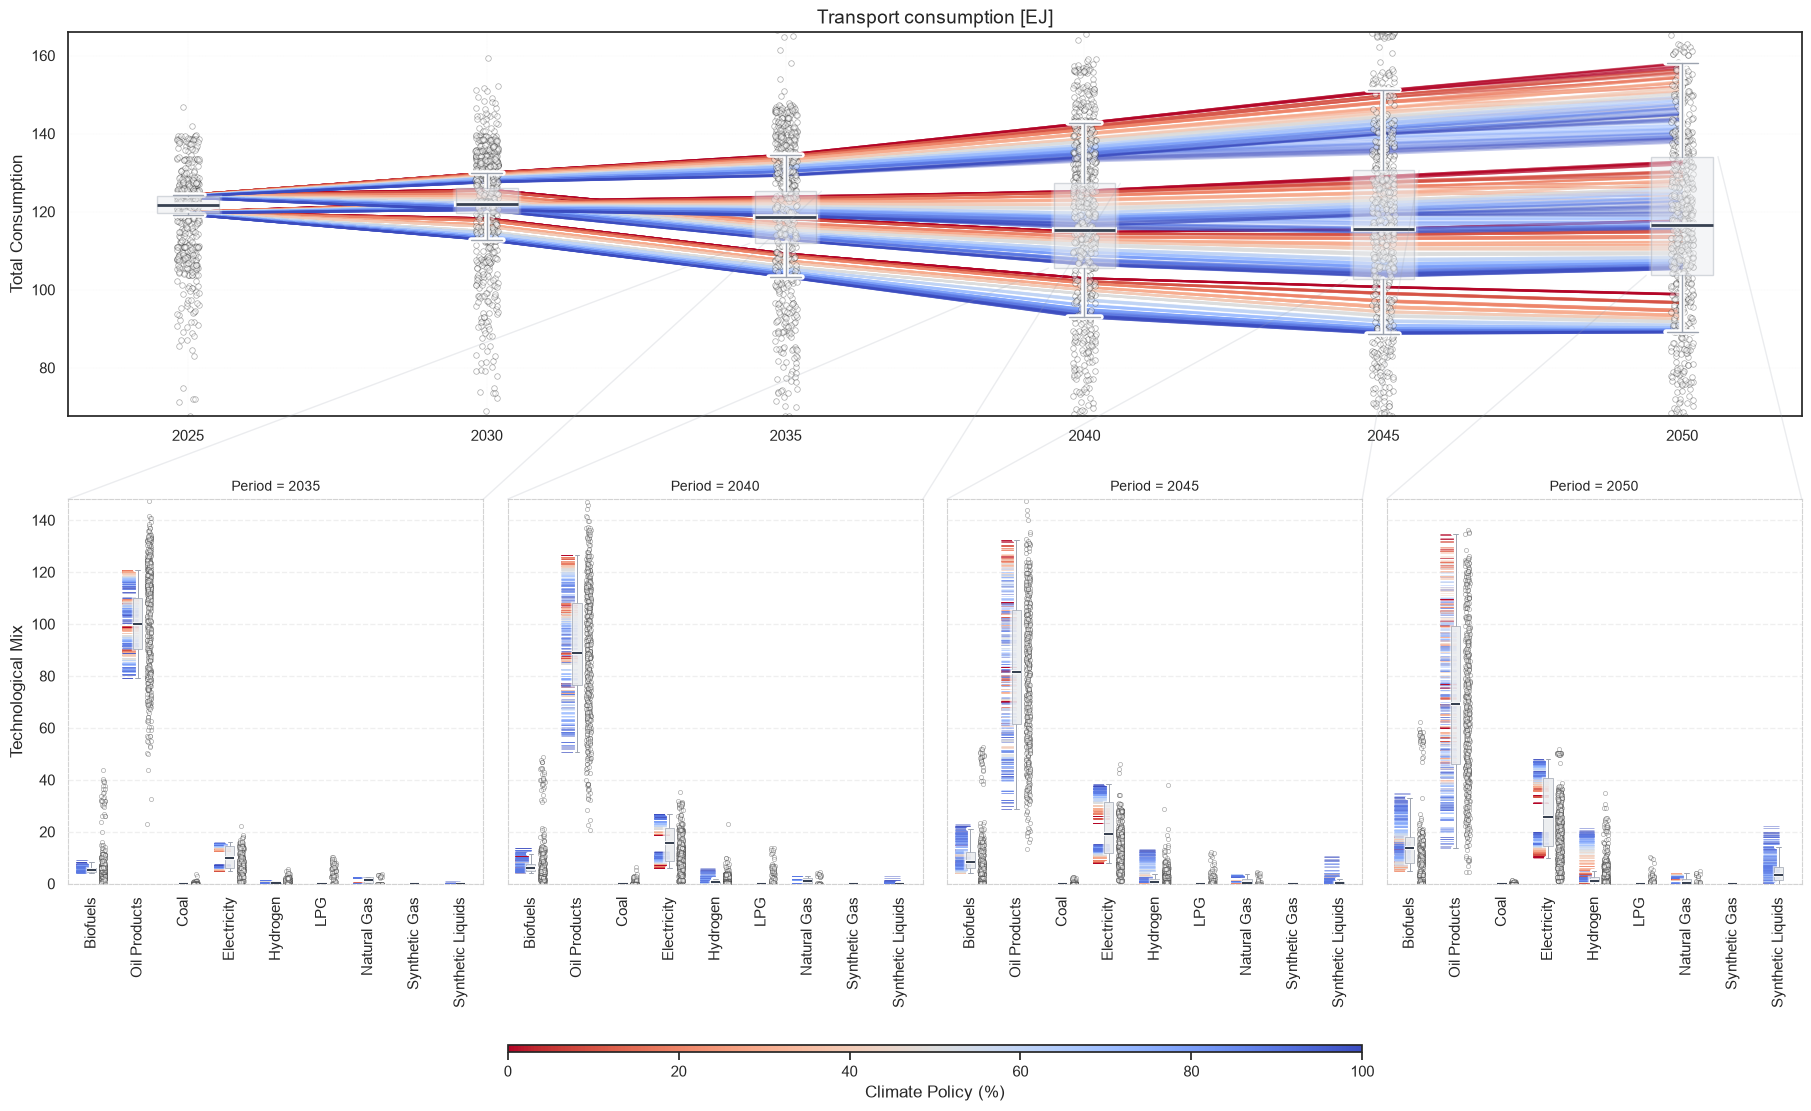

In [19]:
# Categorical columns
policy_levels = [0,20,40,60,80,100]
categorical = {"ClimatePolicy": policy_levels}

# Define index columns and aggregating column names
index_col = ["Case","Region","Period","ClimatePolicy"]
aggregating_columns_names = {
    "Biofuels": ["TRABDS", "TRABGS", "TRABJT"],
    "Oil Products": ["TRADST", "TRAGSL", "TRAHFO", "TRAJTK"],
    "Coal": ["TRACOA"],
    "Electricity": ["TRAELC"],
    "Hydrogen": ["TRAHH2"],
    "LPG": ["TRALPG"],
    "Natural Gas": ["TRANGA"],
    "Synthetic Gas": ["TRASYG"],
    "Synthetic Liquids": ["TRASYL"],
    "Total Consumption": ["TRATOT"],
}

# Filtering parameters
periods =  [2025, 2030, 2035, 2040, 2045, 2050]
ref_periods = [2025, 2030, 2035, 2040, 2045, 2050]
regions = [ "World"]
row_filters = {"Region": regions, "Period": periods}

# AR6 mapping
reference_index_col = ["Model","Region","Year","Scenario","Category"]
reference_aggregating_columns_names = {
    "Biofuels": ["Final Energy|Transportation|Liquids|Bioenergy"],
    "Oil Products": ["Final Energy|Transportation|Liquids|Oil"],
    "Coal": ["Final Energy|Transportation|Liquids|Coal"],
    "Electricity": ["Final Energy|Transportation|Electricity"],
    "Hydrogen": ["Final Energy|Transportation|Hydrogen"],
    "LPG": ["Final Energy|Transportation|Liquids|Natural Gas"],
    "Natural Gas": ["Final Energy|Transportation|Gases|Fossil"],
    "Synthetic Gas": [],
    "Synthetic Liquids": [
        "Final Energy|Transportation|Liquids|Fossil synfuel"
    ],
    "Total Consumption": ["Final Energy|Transportation"],
}

# Define reference row filters and NaN values
categories = ["C1","C2","C3","C4"]
reference_row_filters = {"Year": ref_periods, "Category": categories}
reference_nan_values = [0]

# Names
display = {
    'Grid': 'Period', 'Zoom Grid': [2035, 2040, 2045, 2050],
    'Yaxis': "Transport consumption [EJ]",
    'ColorStrip': "ClimatePolicy"}

options = {
    'rasterized': True
}

myplot = LineZoomHistGridPlot(
    data=data,
    index_col=index_col,
    row_filters=row_filters,
    col_names=aggregating_columns_names,
    reference_data=ar6,
    reference_index_col=reference_index_col,
    reference_row_filters=reference_row_filters,
    reference_col_names=reference_aggregating_columns_names,
    reference_nan_values=reference_nan_values,
    display=display,
    options=options
)

myplot.plot() 
plt.show()

## Figure 20
<a id="figure-20"></a>

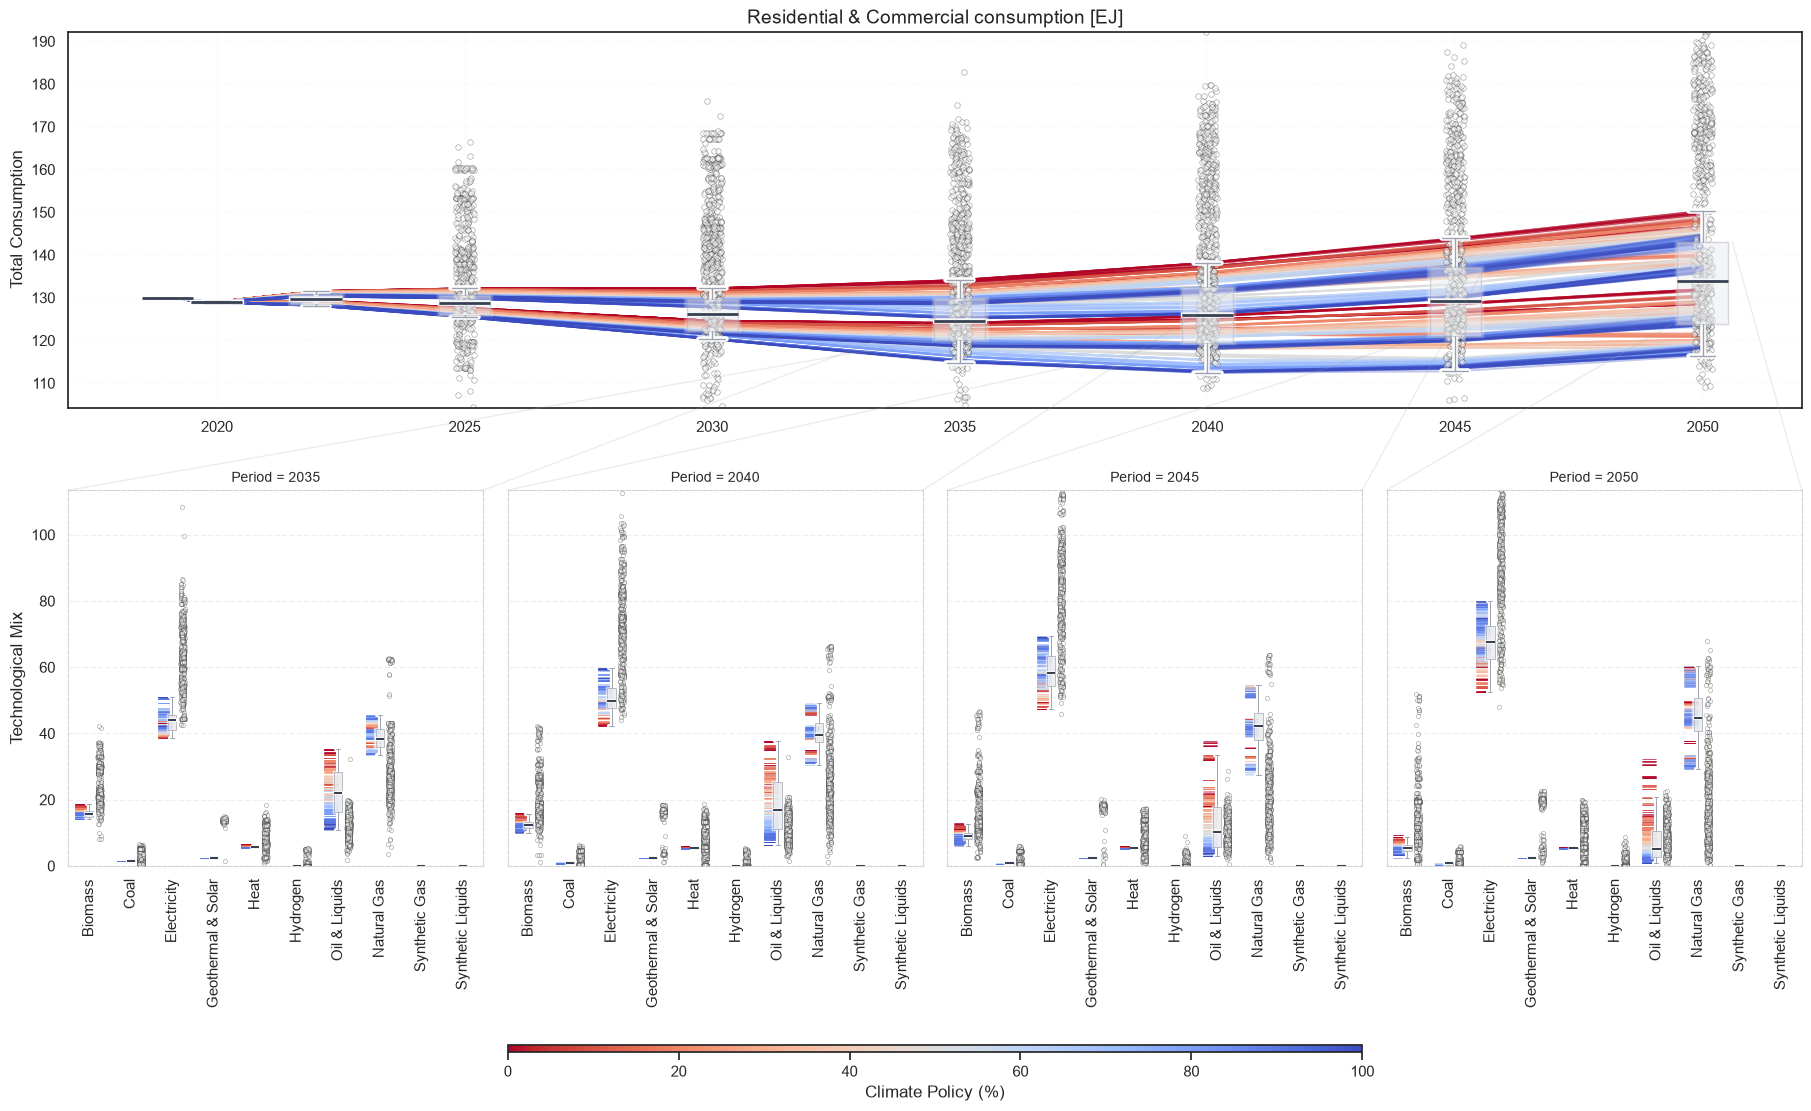

In [20]:
# Categorical columns
policy_levels = list(range(0,101,10))
categorical = {"ClimatePolicy": policy_levels}

# Define index columns and aggregating column names
index_col = ["Case","Region","Period","ClimatePolicy"]
aggregating_columns_names = {
    "Biomass": ["BLGBIO"],
    "Coal": ["BLGCOA"],
    "Electricity": ["BLGELC"],
    "Geothermal & Solar": ["BLGGEO", "BLGSTH"],
    "Heat": ["BLGHET"],
    "Hydrogen": ["BLGHH2"],
    "Oil & Liquids": ["BLGKER", "BLGLPG", "BLGOIL"],
    "Natural Gas": ["BLGNGA", "BLGNGD"],
    "Synthetic Gas": ["BLGSYG"],
    "Synthetic Liquids": ["BLGSYL"],
    "Total Consumption": ["BLGTOT"],
}

# Filtering parameters
periods =  [2019, 2020, 2022, 2025, 2030, 2035, 2040, 2045, 2050]
ref_periods = [2025, 2030, 2035, 2040, 2045, 2050]
regions = [ "World"]
row_filters = {"Region": regions, "Period": periods}

# AR6 mapping
reference_index_col = ["Model","Region","Year","Scenario","Category"]
reference_aggregating_columns_names = {
    "Biomass": ["Final Energy|Residential and Commercial|Solids|Biomass"],
    "Coal": ["Final Energy|Residential and Commercial|Solids|Coal"],
    "Electricity": ["Final Energy|Residential and Commercial|Electricity"],
    "Geothermal & Solar": [
        "Final Energy|Residential and Commercial|Other"
    ],
    "Heat": ["Final Energy|Residential and Commercial|Heat"],
    "Hydrogen": ["Final Energy|Residential and Commercial|Hydrogen"],
    "Oil & Liquids": ["Final Energy|Residential and Commercial|Liquids"],
    "Natural Gas": ["Final Energy|Residential and Commercial|Gases"],
    "Synthetic Gas": [], 
    "Synthetic Liquids": [],
    "Total Consumption": ["Final Energy|Residential and Commercial"],
}

# Define reference row filters and NaN values
categories = ["C1","C2","C3","C4"]
reference_row_filters = {"Year": ref_periods, "Category": categories}
reference_nan_values = [0]

# Names
display = {
    'Grid': 'Period', 'Zoom Grid': [2035, 2040, 2045, 2050],
    'Yaxis': "Residential & Commercial consumption [EJ]",
    'ColorStrip': "ClimatePolicy"}

options = {
    'rasterized': True
}

myplot = LineZoomHistGridPlot(
    data=data,
    index_col=index_col,
    row_filters=row_filters,
    col_names=aggregating_columns_names,
    reference_data=ar6,
    reference_index_col=reference_index_col,
    reference_row_filters=reference_row_filters,
    reference_col_names=reference_aggregating_columns_names,
    reference_nan_values=reference_nan_values,
    display=display,
    options=options
)

myplot.plot()
plt.show()